# 1. Carga de Datos

## Importación de Librerías y Configuración del Entorno

In [1]:
import os
import time
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


import warnings

# --- CONFIGURACIÓN DE LIMPIEZA ---
# Ignoramos FutureWarnings (cambios de sintaxis) y UserWarnings (errores de fuentes/glyphs)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)



# --- 1. RESETEO TOTAL DE ESTILOS ---
# Esto borra cualquier configuración "fantasma" que estuviera volviendo blancas las líneas
plt.rcdefaults() 


# --- 1. CONFIGURACIÓN DE ESTILO GLOBAL ---
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
# Colores personalizados
color_accent = "#2E86C1"  # Azul profesional
color_scatter = "#16A085" # Verde mar
palette_cat = "viridis"   # Paleta para categorías

## Importación de Librerías y Carga de Datos

Esta celda realiza las siguientes operaciones:

1.  **Importación de Bibliotecas:** Carga módulos estándar (`os`, `time`, `math`) y librerías de análisis de datos (`pandas`, `matplotlib`, `seaborn`, `statsmodels`, `scipy`) requeridos para el análisis exploratorio y estadístico.
2.  **Ingesta de Datos:** Lee el archivo fuente Excel desde la ruta local especificada.
3.  **Seguridad de Datos:** Almacena los datos originales en `df_raw` (respaldo) y genera una copia independiente `df` para el procesamiento, evitando modificaciones accidentales al conjunto original.
4.  **Monitoreo:** Mide el tiempo de ejecución y valida la existencia del archivo mediante manejo de excepciones (`try-except`).

In [2]:
 # --- Definición de Ruta ---
file_path = r'D:\WORKSPACE\CUGDL\IACD\2025B\PJ_ESCAMA_MARINA\Data_Frames\escama_marina_Jalisco_2010-2021.xlsx'

print(f"Iniciando carga de datos desde: {file_path}...")

# --- Ingesta de Datos ---
start_time = time.time()

try:
    # 1. Carga del dataset crudo (Respaldo inmutable)
    df_raw = pd.read_excel(file_path)
    
    # Fin del cronómetro
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    print(f"✅ Carga exitosa.")
    print(f"   - Tiempo de ejecución: {elapsed_time:.4f} segundos")

except FileNotFoundError:
    print(f"❌ Error: El archivo no se encuentra en la ruta especificada.")
except Exception as e:
    print(f"❌ Error crítico al cargar los datos: {e}")

Iniciando carga de datos desde: D:\WORKSPACE\CUGDL\IACD\2025B\PJ_ESCAMA_MARINA\Data_Frames\escama_marina_Jalisco_2010-2021.xlsx...
✅ Carga exitosa.
   - Tiempo de ejecución: 24.5046 segundos


## Checkpoint: Generación de Copia de Trabajo

Se crea una copia independiente (`df`) del conjunto de datos original (`df_raw`). Esta práctica garantiza la integridad de los datos crudos, permitiendo realizar limpiezas y transformaciones en `df` sin alterar la fuente original.

> **Optimización de Flujo:** Esta celda funciona como un **punto de restauración**. Dado que la carga inicial de datos consume tiempo (~30 seg), generar esta copia nos permite iterar pruebas y corregir errores reiniciando desde aquí, evitando la necesidad de recargar todo el dataset desde el disco en cada intento.

In [3]:
# Creación de copia de trabajo
df = df_raw.copy()

print(f"✅ Checkpoint Exitoso.")
print(f"- Dataset original preservado en 'df_raw'. Copia de trabajo asignada a 'df'.")

✅ Checkpoint Exitoso.
- Dataset original preservado en 'df_raw'. Copia de trabajo asignada a 'df'.


# 2. Inspección

## Auditoría Estructural y Calidad Inicial

Esta celda realiza el primer diagnóstico exhaustivo del DataFrame de trabajo (`df`), crucial para la fase de limpieza:

1.  **Dimensiones:** Reporta el número total de filas y columnas, estableciendo el tamaño de la muestra.
2.  **Tipos de Datos:** Lista cada columna con su tipo asignado (`dtype`). Esto es esencial para verificar si los datos numéricos, categóricos y temporales fueron inferidos correctamente por pandas.
3.  **Valores Faltantes:** Cuantifica los valores nulos (`NaN`) por columna.
4.  **Duplicidad:** Identifica el número de filas que son duplicados exactos, evaluando la redundancia del dataset.

In [4]:
print("--- Auditoría de Estructura Inicial ---")

# 1. Visualización de Dimensiones
print(f"Dimensiones del DataFrame (Filas x Columnas): {df.shape}")

# 2. Listado de Variables y Tipos
print("\n--- Listado de Variables y Tipos ---")
print(f"{'Nombre de la Columna':<30} | {'Tipo de Dato'}")
print("-" * 50)

for col, dtype in df.dtypes.items():
    print(f"{col:<30} | {dtype}")

# 3. Detección de Valores Nulos
print("\n--- Diagnóstico de Valores Nulos ---")
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]

if not null_counts.empty:
    print("Columnas con valores nulos:")
    print(null_counts.sort_values(ascending=False).to_string())
else:
    print("✅ No se encontraron valores nulos en el dataset.")

# 4. Detección de Duplicados Exactos
print("\n--- Diagnóstico de Duplicados ---")
duplicados = df.duplicated().sum()
print(f"Registros duplicados exactos: {duplicados}")

--- Auditoría de Estructura Inicial ---
Dimensiones del DataFrame (Filas x Columnas): (52789, 35)

--- Listado de Variables y Tipos ---
Nombre de la Columna           | Tipo de Dato
--------------------------------------------------
ID                             | int64
FuenteInformacion              | object
ClaveSitioDesembarque          | int64
NombreSitioDesembarque         | object
RnpaUnidadEconomica            | int64
UnidadEconomica                | object
EstadoRepublica                | object
ClaveOficina                   | int64
NombreOficina                  | object
TipoAvisoArribo                | object
FolioAvisoArribo               | object
FechaAviso                     | datetime64[ns]
Origen                         | object
ClaveLugarCaptura              | int64
NombreLugarCaptura             | object
NumeroEmbarcaciones            | int64
Mes                            | object
Anho                           | int64
PeriodoInicio                  | datetime64[ns

## Validación de Reglas de Negocio y Lógica de Datos

Esta celda evalúa la integridad semántica de los datos aplicando reglas de dominio específicas:

1.  **Auditoría de Errores Lógicos:** Verifica condiciones imposibles como pesos o cantidades negativas, y rangos de tiempo inválidos (ej. días efectivos > 366).
2.  **Consistencia Temporal:** Compara las variables `Duracion` (tiempo total de viaje) y `DiasEfectivos` (tiempo de pesca real). Lógicamente, la duración debe ser mayor o igual a los días efectivos.
3.  **Heurística de Decisión:** Emite una recomendación automática sobre si conservar o eliminar la columna `Duracion` basándose en el volumen de incoherencias detectadas (umbral del 50%).

In [5]:
# Definición de máscaras lógicas
# Se precalcula la inconsistencia de duración para reutilizarla en el análisis final
mask_inconsistencia_duracion = df['Duracion'] < df['DiasEfectivos']

condiciones = {
    "PesoDesembarcadoKg <= 0": df['PesoDesembarcadoKg'] <= 0,
    "NumeroEmbarcaciones <= 0": df['NumeroEmbarcaciones'] <= 0,
    "Duracion Negativa": df['Duracion'] < 0,
    "DiasEfectivos Absurdos (>366 o <=0)": (df['DiasEfectivos'] > 366) | (df['DiasEfectivos'] <= 0),
    "Inconsistencia Duracion < DiasEfectivos": mask_inconsistencia_duracion
}

print("--- Reporte de Errores Lógicos ---")
total_registros = len(df)

# Iteración y reporte de fallos
for error, mask in condiciones.items():
    cantidad = mask.sum()
    porcentaje = (cantidad / total_registros) * 100
    flag = "⚠️" if cantidad > 0 else "✅"
    print(f"{flag} {error}: {cantidad} registros ({porcentaje:.2f}%)")

# Análisis de decisión para la columna 'Duracion'
print("\n--- Análisis de Viabilidad: Duracion vs DiasEfectivos ---")
cnt_inconsistencias = mask_inconsistencia_duracion.sum()
print(f"Registros donde Duracion < DiasEfectivos: {cnt_inconsistencias}")

if cnt_inconsistencias > (total_registros * 0.5):
    print("-> SUGERENCIA: Inconsistencias masivas en 'Duracion'. Considerar ELIMINAR columna.")
else:
    print("-> SUGERENCIA: La columna 'Duracion' es mayormente viable. Mantener y limpiar errores puntuales.")

--- Reporte de Errores Lógicos ---
⚠️ PesoDesembarcadoKg <= 0: 18 registros (0.03%)
⚠️ NumeroEmbarcaciones <= 0: 72 registros (0.14%)
⚠️ Duracion Negativa: 218 registros (0.41%)
⚠️ DiasEfectivos Absurdos (>366 o <=0): 11 registros (0.02%)
⚠️ Inconsistencia Duracion < DiasEfectivos: 28411 registros (53.82%)

--- Análisis de Viabilidad: Duracion vs DiasEfectivos ---
Registros donde Duracion < DiasEfectivos: 28411
-> SUGERENCIA: Inconsistencias masivas en 'Duracion'. Considerar ELIMINAR columna.


# 3. Limpieza

## Limpieza Integral y Depuración del Dataset

En esta sección se ejecuta un proceso unificado de limpieza para garantizar la calidad de los datos antes del análisis exploratorio. El proceso se divide en tres etapas críticas:

### 1. Filtrado de Registros (Limpieza de Filas)
Se eliminan registros que presentan inconsistencias lógicas o biológicas imposibles:
* **Eliminación Estructural:** Se descarta la columna `'Duracion'` por inconsistencias previas detectadas.
* **Máscara de Validez:** Se conservan únicamente los registros que cumplen con:
    * `PesoDesembarcadoKg` > 0 (Capturas reales).
    * `NumeroEmbarcaciones` > 0 (Esfuerzo pesquero existente).
    * `DiasEfectivos` > 0 y <= 366 (Rangos de tiempo coherentes con un año calendario).

### 2. Reducción de Dimensionalidad (Limpieza de Columnas)
Una vez filtradas las filas válidas, se optimizan las variables del dataset:
* **Varianza Cero:** Se eliminan automáticamente las columnas que contienen un único valor constante en todos los registros, ya que no aportan información estadística (varianza = 0).
* **Limpieza Semántica:** Se eliminan identificadores administrativos (`ID`, `Folios`, `Claves`) y fechas de trámite (`FechaAviso`, `FechaExpedicion`) que no son relevantes para el análisis biológico-pesquero.

### 3. Validación y Reporte
Se imprime un resumen del impacto de la limpieza (porcentaje de datos eliminados) y se realiza un *Sanity Check* verificando los valores mínimos de las variables críticas para asegurar que no quedan ceros ni negativos.

In [6]:
# --- 1. CAPTURA DE MÉTRICAS INICIALES ---
n_registros_inicial = df.shape[0]

# --- 2. LIMPIEZA DE FILAS (REGISTROS) ---

# Eliminación de columna 'Duracion' (Inconsistencia crítica)
if 'Duracion' in df.columns:
    df.drop(columns=['Duracion'], inplace=True)
    print("🗑️ Columna 'Duracion' eliminada (pre-filtro).")

# Definición de máscara lógica para conservar solo registros válidos
mask_validez = (
    (df['PesoDesembarcadoKg'] > 0) &
    (df['NumeroEmbarcaciones'] > 0) &
    (df['DiasEfectivos'] > 0) & 
    (df['DiasEfectivos'] <= 366)
)

# Aplicación del filtro
df = df[mask_validez].copy()

# --- 3. LIMPIEZA DE COLUMNAS (ESTRUCTURA Y METADATOS) ---

# A) Reducción por Varianza Cero (Columnas constantes)
# Nota: Se hace DESPUÉS del filtro de filas para detectar constantes reales en la data válida
cols_constantes = [col for col in df.columns if df[col].nunique() <= 1]

if cols_constantes:
    df.drop(columns=cols_constantes, inplace=True)
    print(f"📉 Se eliminaron {len(cols_constantes)} columnas constantes (Varianza 0).")
    # print(f"   {cols_constantes}") # Descomentar si se desea ver la lista
else:
    print("ℹ️ No se detectaron columnas constantes.")

# B) Eliminación Semántica (IDs y Fechas Administrativas)
cols_ids_fechas = [
    'ID', 'FolioAvisoArribo', 'NumeroPermiso', 'RnpaUnidadEconomica',
    'ClaveSitioDesembarque', 'ClaveOficina', 'ClaveLugarCaptura', 'ClaveEspecie', 
    'FechaAviso', 'PeriodoInicio', 'PeriodoFinal', 'FechaExpedicion', 'FechaVigencia'
]
cols_a_borrar = [c for c in cols_ids_fechas if c in df.columns]

if cols_a_borrar:
    df.drop(columns=cols_a_borrar, inplace=True)
    print(f"🗑️ Se eliminaron {len(cols_a_borrar)} columnas administrativas (IDs/Fechas).")

# --- 4. REPORTE FINAL E INTEGRIDAD ---
n_registros_final = df.shape[0]
n_eliminados = n_registros_inicial - n_registros_final
pct_eliminados = (n_eliminados / n_registros_inicial) * 100 if n_registros_inicial > 0 else 0

print(f"\n--- RESUMEN DE LIMPIEZA ---")
print(f"Registros iniciales:      {n_registros_inicial}")
print(f"Registros finales:        {n_registros_final}")
print(f"❌ Registros eliminados:  {n_eliminados} ({pct_eliminados:.2f}%)")

print("\n--- Verificación de Mínimos (Sanity Check) ---")
cols_check = ['PesoDesembarcadoKg', 'NumeroEmbarcaciones', 'DiasEfectivos']
# Solo mostramos las columnas que aún existen en el DF
print(df[[c for c in cols_check if c in df.columns]].min())

print("\n--- Estructura Final del Dataset ---")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
# print(f"Variables Activas: {df.columns.tolist()}") # Opcional: imprimir lista completa

🗑️ Columna 'Duracion' eliminada (pre-filtro).
📉 Se eliminaron 4 columnas constantes (Varianza 0).
🗑️ Se eliminaron 13 columnas administrativas (IDs/Fechas).

--- RESUMEN DE LIMPIEZA ---
Registros iniciales:      52789
Registros finales:        52688
❌ Registros eliminados:  101 (0.19%)

--- Verificación de Mínimos (Sanity Check) ---
PesoDesembarcadoKg     1.0
NumeroEmbarcaciones    1.0
DiasEfectivos          1.0
dtype: float64

--- Estructura Final del Dataset ---
Dimensiones: 52688 filas x 17 columnas


## Transformación y Tipado Estricto de Variables

Esta celda realiza la normalización técnica de los tipos de datos para preparar el dataset para el modelado estadístico:

1.  **Codificación Ordinal (Meses):** Transforma la variable `Mes` de texto a valores numéricos (1-12). Esto corrige inconsistencias de escritura y habilita el análisis de estacionalidad cronológica correcta.
2.  **Optimización de Memoria:** Convierte todas las variables nominales (texto) al tipo de dato `category`. Esto reduce significativamente el uso de memoria y acelera las operaciones de agrupamiento en Pandas.
3.  **Coerción de Enteros:** Fuerza a las variables discretas (`Anho`, `NumeroEmbarcaciones`, `DiasEfectivos`) al tipo `int64`, eliminando cualquier representación decimal flotante residual.

In [7]:
# 1. Normalización de Variable Temporal: Meses
mapa_meses = {
    'ENERO': 1, 'FEBRERO': 2, 'MARZO': 3, 'ABRIL': 4, 'MAYO': 5, 'JUNIO': 6,
    'JULIO': 7, 'AGOSTO': 8, 'SEPTIEMBRE': 9, 'OCTUBRE': 10, 'NOVIEMBRE': 11, 'DICIEMBRE': 12
}

if 'Mes' in df.columns:
    print("🔄 Normalizando columna 'Mes' (Texto -> Numérico)...")
    # Estandarización de cadena y mapeo directo
    df['Mes'] = df['Mes'].astype(str).str.upper().str.strip().map(mapa_meses)
    
    # Gestión de errores de mapeo (nulos generados por typos)
    nulos_mes = df['Mes'].isnull().sum()
    if nulos_mes > 0:
        print(f"⚠️ Se eliminaron {nulos_mes} registros con formato de mes inválido.")
        df.dropna(subset=['Mes'], inplace=True)

# 2. Optimización de Memoria: Variables Categóricas
# Se convierten objetos a 'category' para eficiencia, excluyendo 'Mes' que ya es numérico
cols_texto = df.select_dtypes(include=['object']).columns
cols_texto = [c for c in cols_texto if c != 'Mes']

if cols_texto:
    print(f"🔄 Optimizando {len(cols_texto)} variables de texto a tipo 'category'...")
    df[cols_texto] = df[cols_texto].astype('category')

# 3. Coerción de Tipos Numéricos (Enteros)
cols_enteros = ['Mes', 'Anho', 'NumeroEmbarcaciones', 'DiasEfectivos']
cols_validas_int = [c for c in cols_enteros if c in df.columns]

# Conversión segura: Float -> Int64 para manejar posibles decimales .0
df[cols_validas_int] = df[cols_validas_int].astype(float).astype('int64')

# 4. Verificación de Resultados
print("\n--- Tipos de Datos Actualizados ---")
print(df[cols_validas_int].dtypes)
print(f"Valores únicos en 'Mes' (Ordenados): {sorted(df['Mes'].unique())}")

🔄 Normalizando columna 'Mes' (Texto -> Numérico)...
🔄 Optimizando 9 variables de texto a tipo 'category'...

--- Tipos de Datos Actualizados ---
Mes                    int64
Anho                   int64
NumeroEmbarcaciones    int64
DiasEfectivos          int64
dtype: object
Valores únicos en 'Mes' (Ordenados): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


## Análisis Exploratorio Gráfico: Distribuciones y Frecuencias

Esta sección ejecuta un diagnóstico visual exhaustivo de todas las variables del dataset, dividido en dos enfoques según el tipo de dato:

### 1. Variables Numéricas (Detección de Outliers y Forma)
Para cada variable numérica (`int`, `float`), se generan dos gráficos complementarios:
* **Histograma + KDE (Izquierda):** Permite visualizar la **forma de la distribución** (si es normal, sesgada a la derecha/izquierda o bimodal).
* **Boxplot (Derecha):** Especializado en la detección de **valores atípicos (outliers)** y la visualización de la mediana y cuartiles.

### 2. Variables Categóricas (Frecuencia y Esparcidad)
Para las variables de texto o categóricas, se realiza un análisis de cardinalidad y estructura:
* **Diagnóstico de Esparcidad:** El sistema alerta automáticamente si existen categorías con **menos de 5 registros** (Rare Labels), lo cual es crítico para evitar ruido en futuros modelos predictivos.
* **Ranking Top 10:** Se grafican únicamente las **10 categorías más frecuentes** para garantizar la legibilidad, permitiendo identificar rápidamente las clases dominantes sin saturar la visualización con categorías minoritarias.

--- Análisis Gráfico: Distribución y Outliers (8 variables) ---


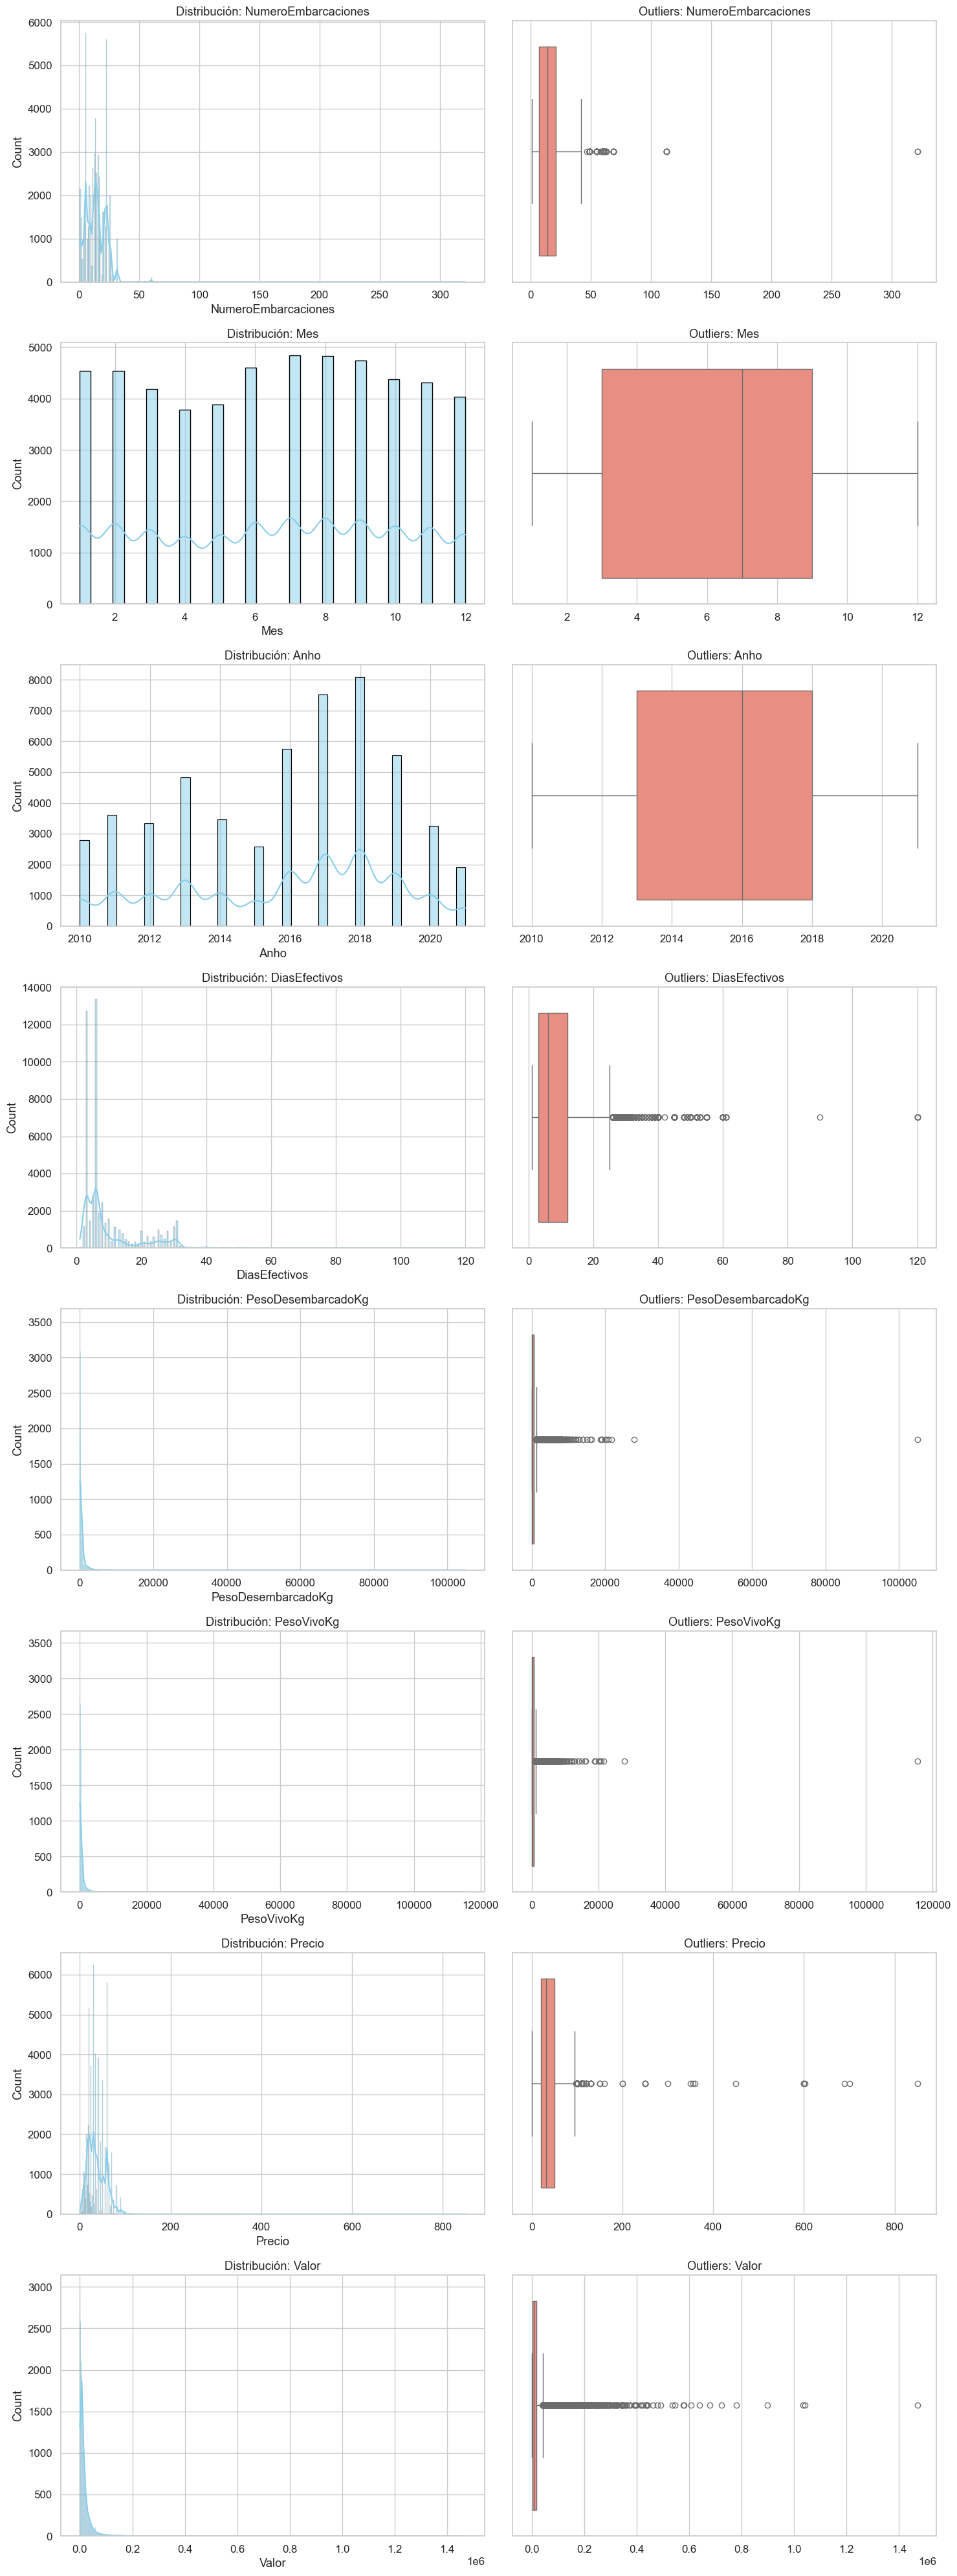


--- Diagnóstico de Estructura Categórica (TOP 10) ---

📊 Variable: NombreSitioDesembarque | Cardinalidad Total: 75
   ⚠️ ALERTA DE ESPARCIDAD: 15 categorías (20.0%) tienen < 5 registros.


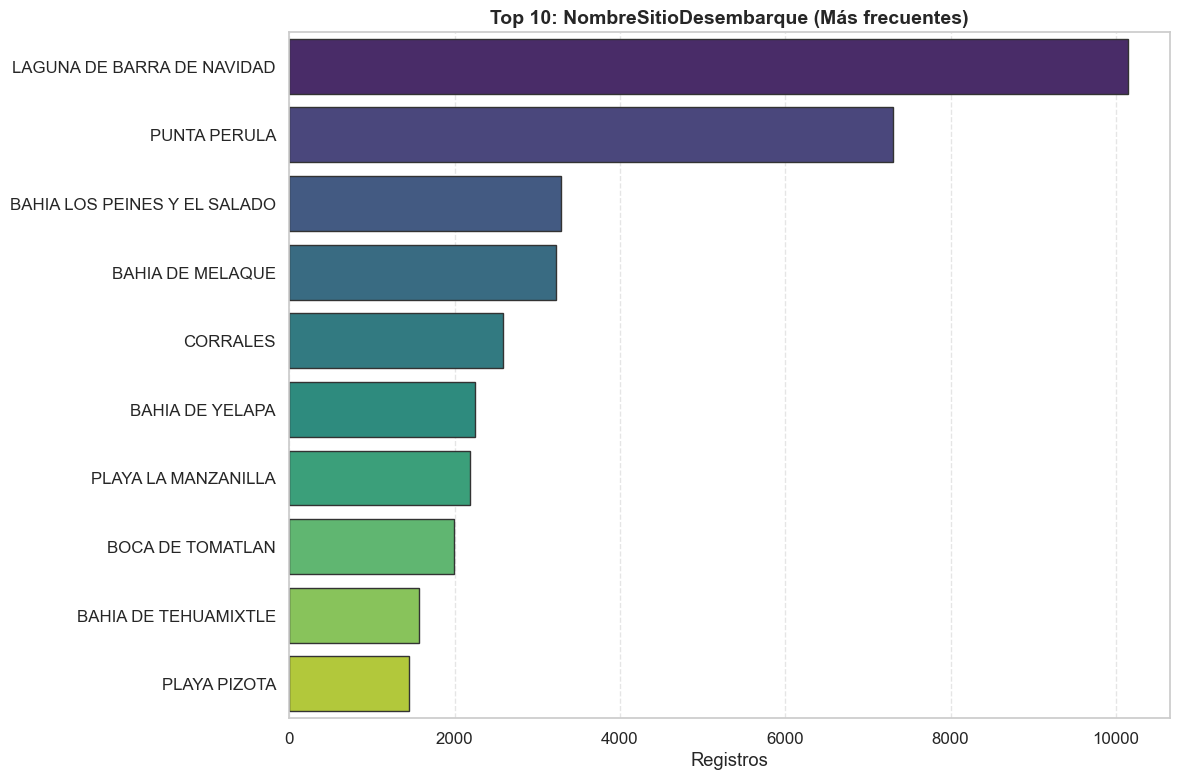

--------------------------------------------------

📊 Variable: UnidadEconomica | Cardinalidad Total: 75
   ⚠️ ALERTA DE ESPARCIDAD: 13 categorías (17.3%) tienen < 5 registros.


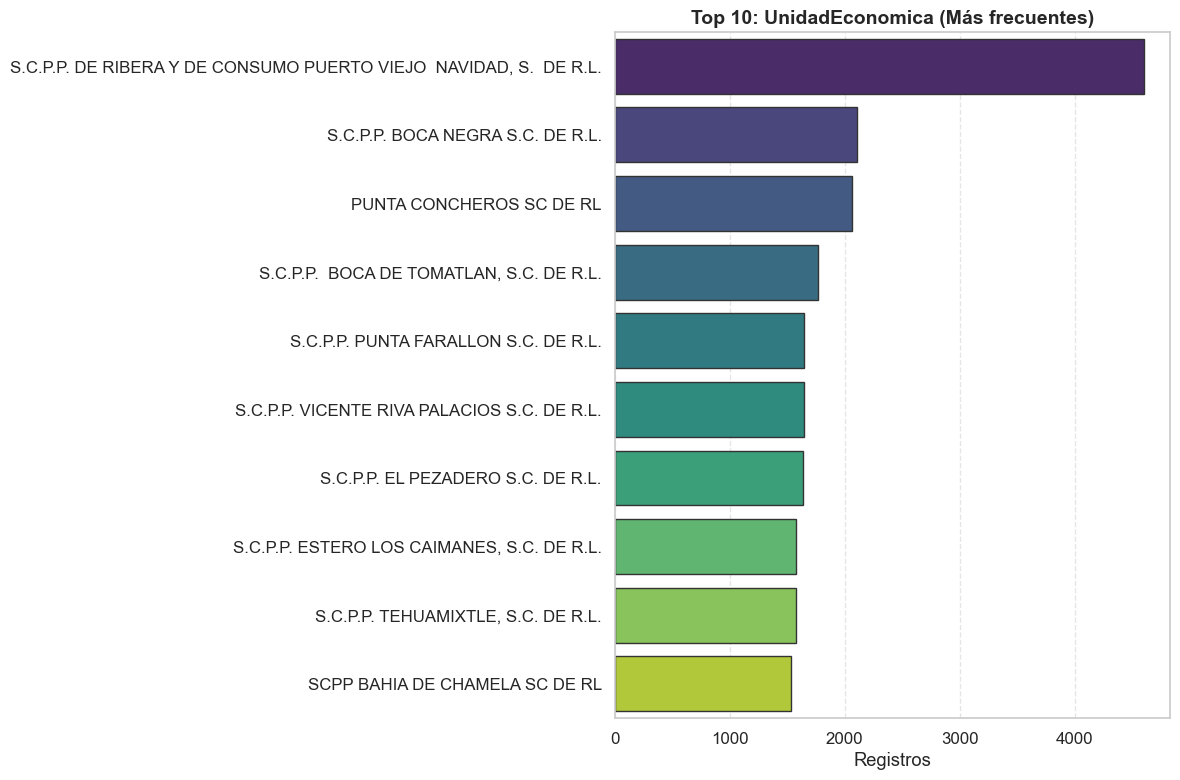

--------------------------------------------------

📊 Variable: NombreOficina | Cardinalidad Total: 4
   ⚠️ ALERTA DE ESPARCIDAD: 1 categorías (25.0%) tienen < 5 registros.


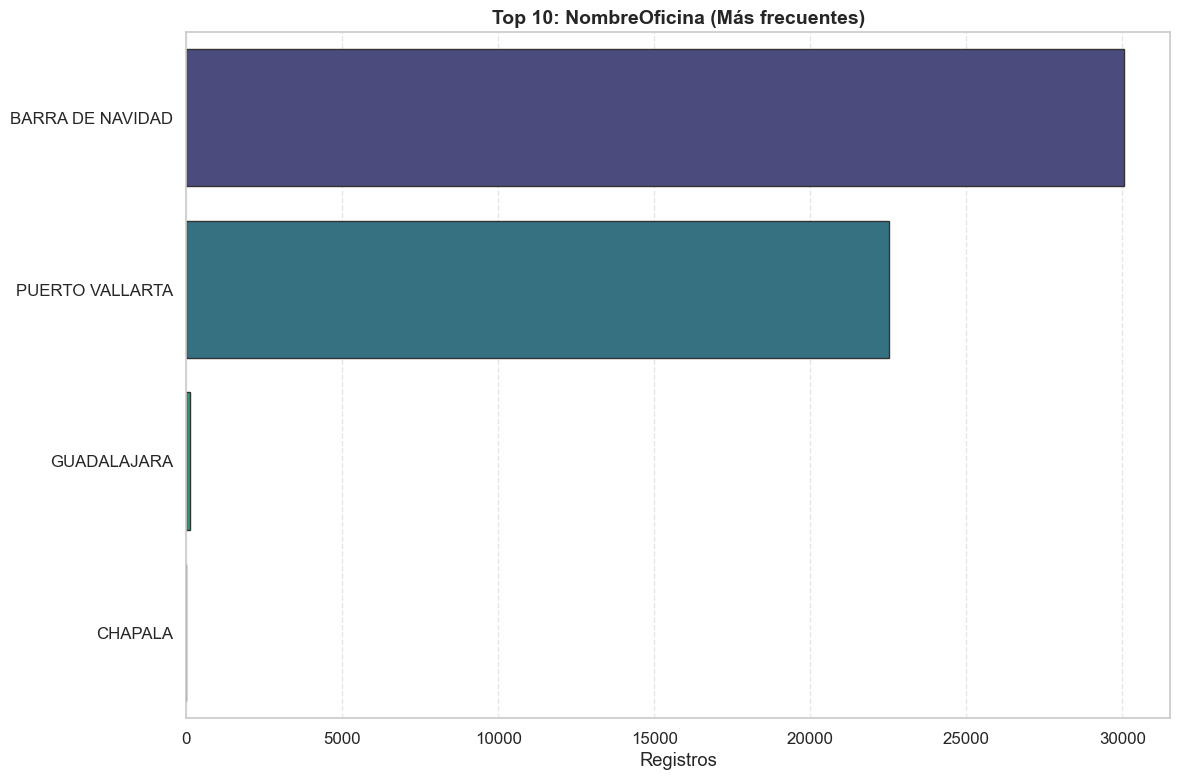

--------------------------------------------------

📊 Variable: Origen | Cardinalidad Total: 2


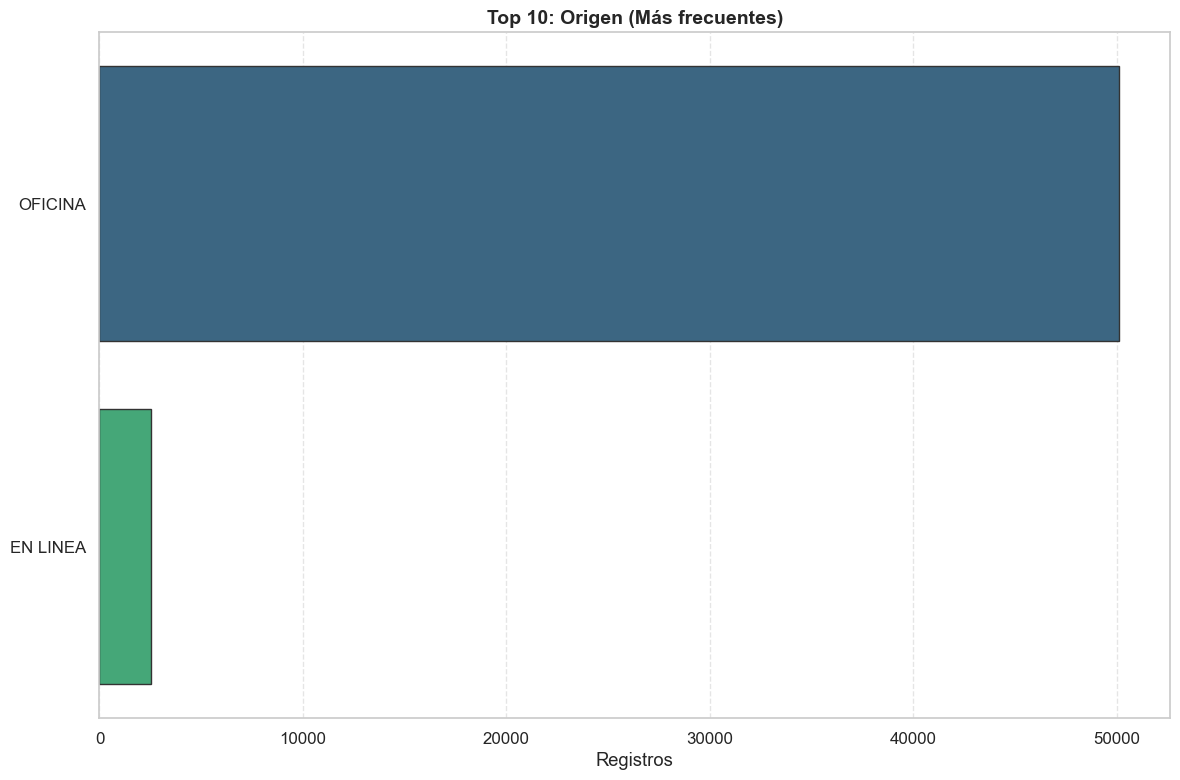

--------------------------------------------------

📊 Variable: NombreLugarCaptura | Cardinalidad Total: 50
   ⚠️ ALERTA DE ESPARCIDAD: 14 categorías (28.0%) tienen < 5 registros.


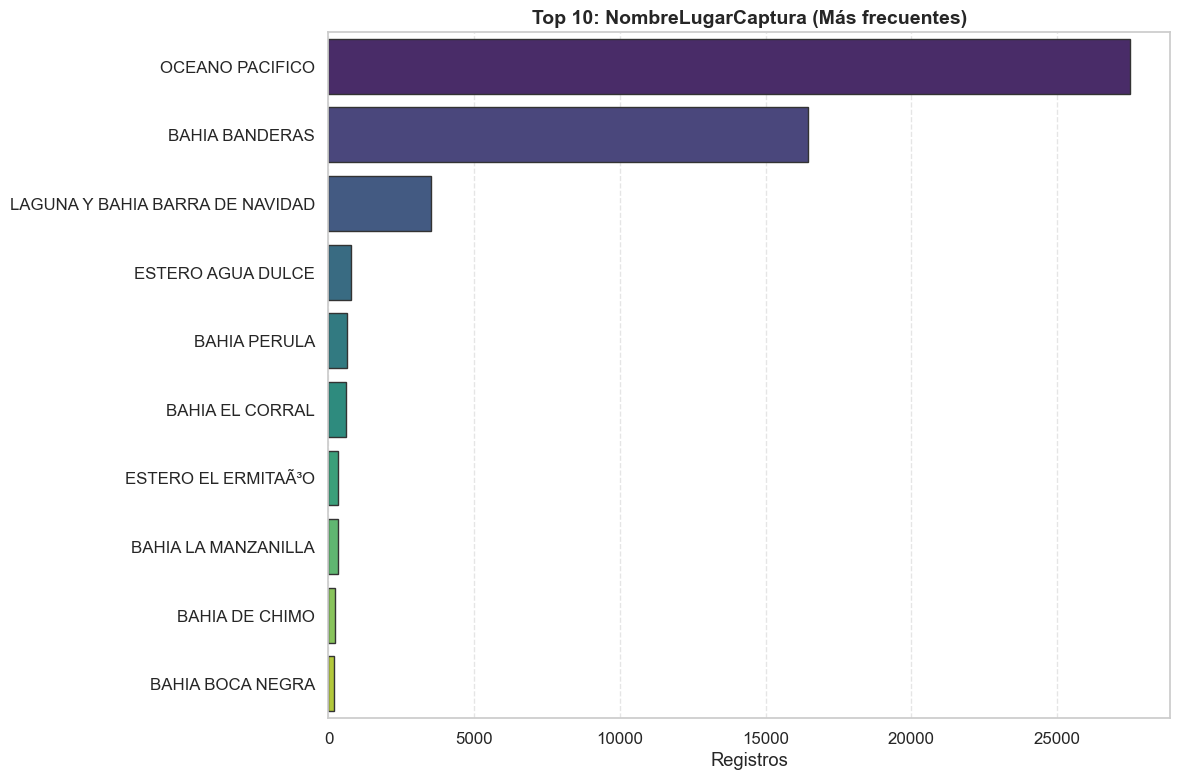

--------------------------------------------------

📊 Variable: TipoZona | Cardinalidad Total: 3


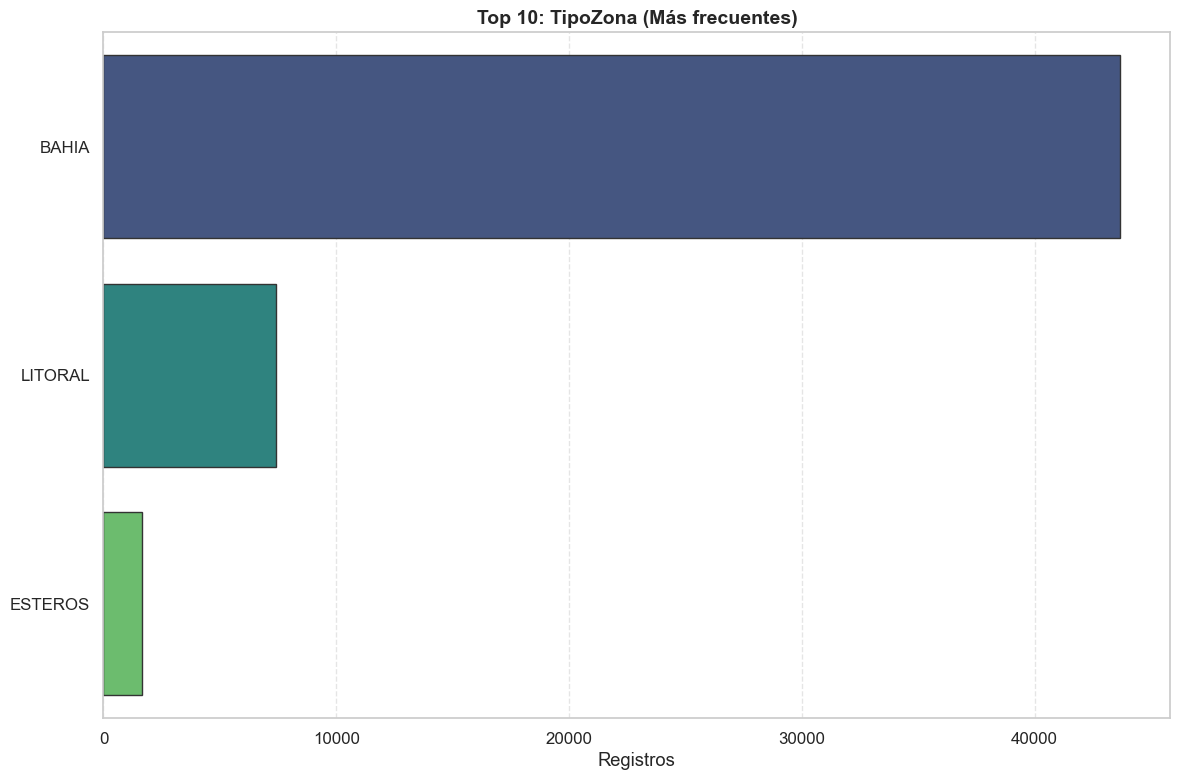

--------------------------------------------------

📊 Variable: ProduccionAcuacultura | Cardinalidad Total: 2


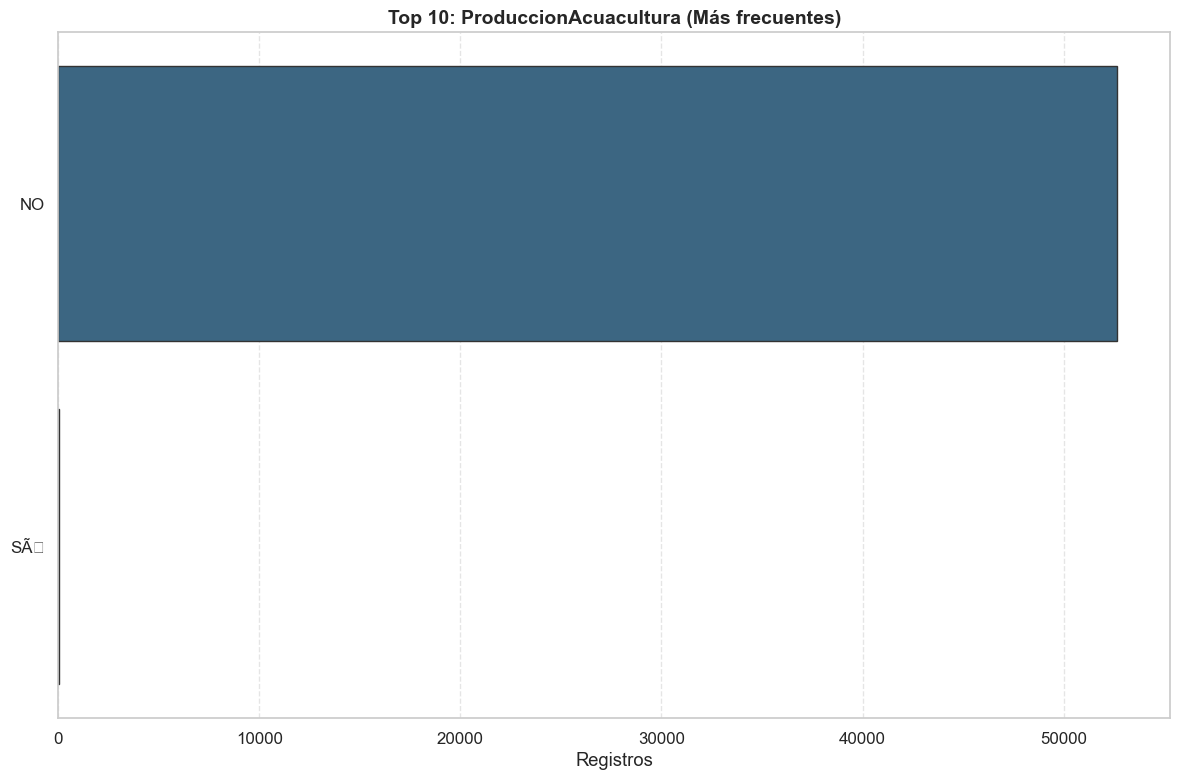

--------------------------------------------------

📊 Variable: NombrePrincipal | Cardinalidad Total: 36
   ⚠️ ALERTA DE ESPARCIDAD: 5 categorías (13.9%) tienen < 5 registros.


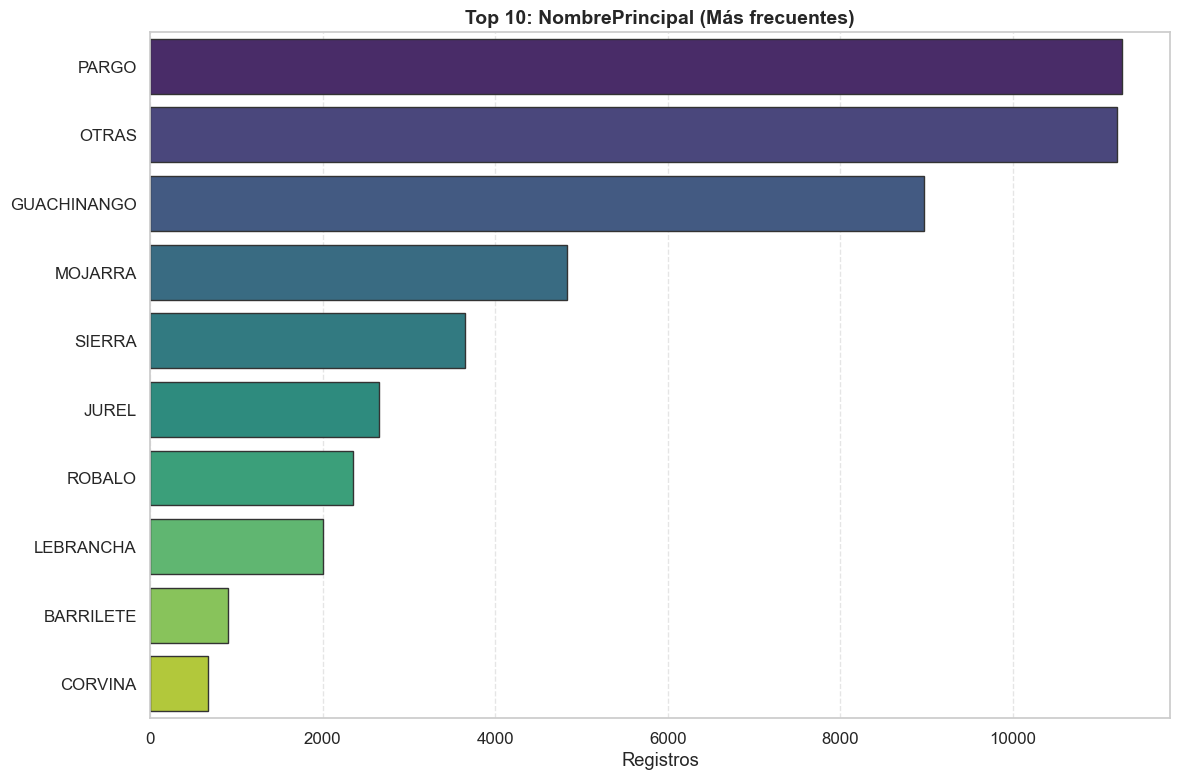

--------------------------------------------------

📊 Variable: NombreEspecie | Cardinalidad Total: 203
   ⚠️ ALERTA DE ESPARCIDAD: 94 categorías (46.3%) tienen < 5 registros.


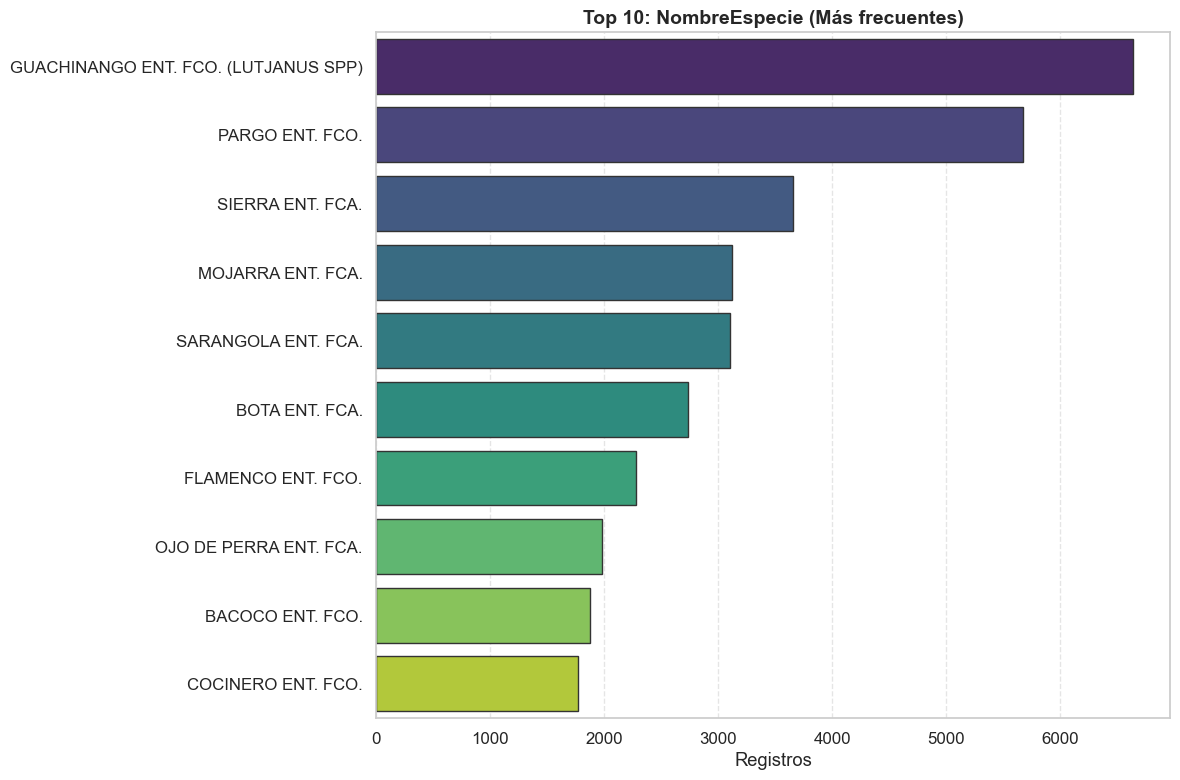

--------------------------------------------------


In [8]:
# --- 1. Análisis de Distribución (Variables Numéricas) ---
cols_num = df.select_dtypes(include=['number']).columns

if len(cols_num) > 0:
    n_vars = len(cols_num)
    fig, axes = plt.subplots(n_vars, 2, figsize=(15, 5 * n_vars))
    if n_vars == 1: axes = [axes] 

    print(f"--- Análisis Gráfico: Distribución y Outliers ({n_vars} variables) ---")

    for i, col in enumerate(cols_num):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i][0], color='skyblue', edgecolor='black')
        axes[i][0].set_title(f'Distribución: {col}')
        
        sns.boxplot(data=df, x=col, ax=axes[i][1], color='salmon')
        axes[i][1].set_title(f'Outliers: {col}')
        axes[i][1].set_xlabel('')

    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ No se detectaron variables numéricas para graficar.")

# --- 2. Análisis de Frecuencia (Variables Categóricas - TOP 10 REAL) ---
cols_cat = df.select_dtypes(include=['category', 'object']).columns

if len(cols_cat) > 0:
    print("\n" + "="*80)
    print("--- Diagnóstico de Estructura Categórica (TOP 10) ---")
    print("="*80)
    
    for col in cols_cat:
        # 1. Contamos y ordenamos descendente
        conteo_total = df[col].value_counts().sort_values(ascending=False)
        n_clases = len(conteo_total)
        
        print(f"\n📊 Variable: {col} | Cardinalidad Total: {n_clases}")
        
        # Alerta de esparcidad
        clases_raras = conteo_total[conteo_total < 5].count()
        if clases_raras > 0:
            pct_raras = (clases_raras / n_clases) * 100
            print(f"   ⚠️ ALERTA DE ESPARCIDAD: {clases_raras} categorías ({pct_raras:.1f}%) tienen < 5 registros.")
        
        # --- GRÁFICO LIMPIO (SOLO TOP 10) ---
        if n_clases > 1:
            # Aumentamos la altura a 8 para que quepan los nombres largos
            plt.figure(figsize=(12, 8)) 
            
            # --- CORRECCIÓN CRÍTICA AQUÍ ---
            # Tomamos el top 10 y convertimos a listas limpias para evitar el solapamiento
            top_10_series = conteo_total.iloc[:10]
            y_labels_clean = top_10_series.index.astype(str).tolist() # Nombres limpios
            x_values_clean = top_10_series.values.tolist() # Valores limpios

            sns.barplot(
                x=x_values_clean, 
                y=y_labels_clean, 
                hue=y_labels_clean, 
                palette="viridis", 
                legend=False,
                edgecolor=".2", linewidth=1
            )
            
            plt.title(f'Top 10: {col} (Más frecuentes)', fontsize=14, fontweight='bold')
            plt.xlabel('Registros')
            plt.ylabel('') # Sin etiqueta en Y para limpiar
            plt.grid(axis='x', linestyle='--', alpha=0.5)
            
            # Ajustar márgenes para que no se corten los nombres largos
            plt.tight_layout() 
            plt.show()
        else:
            print("   (Variable constante, se omite gráfico)")
        
        print("-" * 50)

## Análisis de Correlación y Dependencia Lineal

En esta sección evaluamos las relaciones estadísticas entre las variables numéricas utilizando el **Coeficiente de Correlación de Pearson ($r$)**. El objetivo es doble: entender qué variables influyen en nuestro objetivo y detectar problemas de redundancia.

### 1. Mapa de Calor Estratégico
Se genera una matriz visual donde la variable objetivo (**`PesoVivoKg`**) ha sido desplazada intencionalmente a la última fila y columna. Esto permite un escaneo visual rápido:
* **Colores Rojos:** Correlación positiva (si X sube, el Peso sube).
* **Colores Azules:** Correlación negativa (si X sube, el Peso baja).

### 2. Ranking de Impacto (Feature Importance Preliminar)
Se extrae y ordena la correlación directa de cada variable contra `PesoVivoKg`. Esta tabla nos dice qué variables son los **predictores más fuertes** de manera individual.

### 3. Diagnóstico de Multicolinealidad
Se realiza una auditoría automática para detectar **redundancia entre predictores**.
* **El Problema:** Si dos variables predictoras (ej. `Variable A` y `Variable B`) tienen una correlación extrema ($r > |0.90|$), le dicen "lo mismo" al modelo.
* **La Acción:** Se listan estos pares críticos para considerar eliminar uno de ellos, evitando así inestabilidad en los coeficientes del modelo futuro.

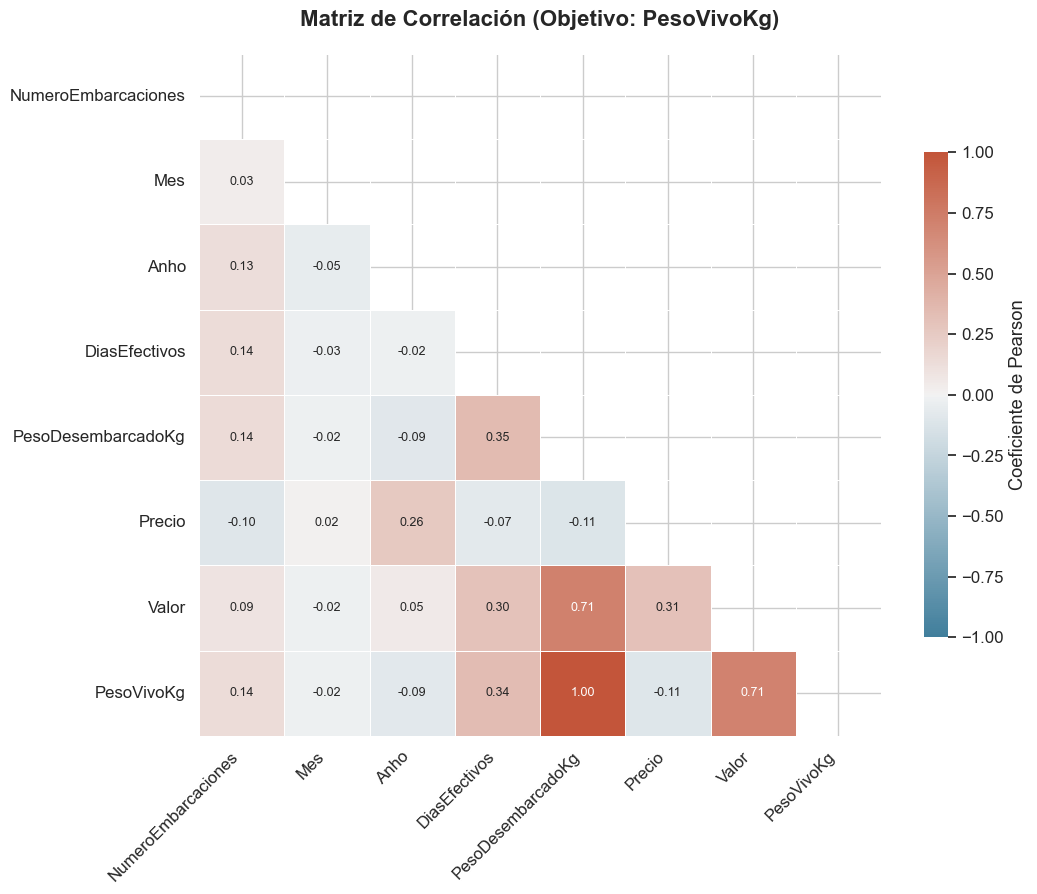


--- 🎯 Impacto de Variables sobre 'PesoVivoKg' ---


,Correlación Pearson
PesoDesembarcadoKg,0.9989
Valor,0.7059
DiasEfectivos,0.3436
NumeroEmbarcaciones,0.1383
Mes,-0.0209
Anho,-0.0855
Precio,-0.1072



--- ⚠️ Diagnóstico de Redundancia (Correlación > |0.90|) ---
✅ No se detectaron pares de variables predictoras con colinealidad crítica.


In [9]:
# AQUÍ ESTABA EL ERROR: Necesitamos definir la variable antes de usarla
target_col = 'PesoVivoKg' 

# 2. Selección de numéricas y cálculo de correlación
df_num = df.select_dtypes(include=['number'])

if not df_num.empty:
    corr_matrix = df_num.corr()

    # --- REORDENAMIENTO ESTRATÉGICO ---
    cols = list(corr_matrix.columns)
    if target_col in cols:
        cols.remove(target_col)
        cols.append(target_col)
        corr_matrix = corr_matrix.reindex(index=cols, columns=cols)
    else:
        print(f"⚠️ Advertencia: '{target_col}' no está en las numéricas.")

    # --- 2. Visualización Gráfica (Heatmap) ---
    plt.figure(figsize=(11, 9))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    heatmap = sns.heatmap(
        corr_matrix, 
        mask=mask, 
        cmap=cmap, 
        vmax=1, vmin=-1, center=0,
        square=True, linewidths=.5, 
        cbar_kws={"shrink": .7, "label": "Coeficiente de Pearson"},
        annot=True, fmt=".2f", annot_kws={"size": 9}
    )
    heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, horizontalalignment='right')
    plt.title(f'Matriz de Correlación (Objetivo: {target_col})', fontsize=16, fontweight='bold', pad=20)
    plt.show()

    # ==============================================================================
    # --- 3. ANÁLISIS ESPECÍFICO DE LA VARIABLE OBJETIVO ---
    # ==============================================================================
    if target_col in corr_matrix.columns:
        print(f"\n--- 🎯 Impacto de Variables sobre '{target_col}' ---")
        
        # Extraemos solo la columna del objetivo y eliminamos la fila del objetivo mismo
        target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
        
        # Convertimos a DataFrame para visualización
        df_target_corr = pd.DataFrame(target_corr)
        df_target_corr.columns = ['Correlación Pearson']
        
        # Mostramos tabla coloreada
        display(
            df_target_corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
            .format({'Correlación Pearson': "{:.4f}"})
        )
    else:
        print(f"ℹ️ No se puede mostrar análisis de objetivo porque '{target_col}' no existe o fue eliminada.")

    # ==============================================================================
    # --- 4. DIAGNÓSTICO DE MULTICOLINEALIDAD (Entre variables predictoras) ---
    # ==============================================================================
    print("\n--- ⚠️ Diagnóstico de Redundancia (Correlación > |0.90|) ---")
    
    criticos = []
    # Iteramos sobre la matriz
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            val = corr_matrix.iloc[i, j]
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            
            # Evitamos reportar correlaciones con el Target
            if col_i == target_col or col_j == target_col:
                continue

            if abs(val) > 0.90:
                criticos.append({
                    'Variable A': col_i,
                    'Variable B': col_j,
                    'Coeficiente': val,
                    'Tipo': 'Positiva Extrema' if val > 0 else 'Negativa Extrema'
                })

    if criticos:
        df_criticos = pd.DataFrame(criticos)
        display(
            df_criticos.style.background_gradient(subset=['Coeficiente'], cmap='Reds', vmin=0.9, vmax=1)
            .format({'Coeficiente': "{:.4f}"})
            .set_caption("Pares de variables predictoras redundantes")
        )
        print("-> Sugerencia: Estas variables dicen 'lo mismo'. Considera eliminar una de cada par.")
    else:
        print("✅ No se detectaron pares de variables predictoras con colinealidad crítica.")

else:
    print("ℹ️ No hay suficientes variables numéricas.")

## Análisis de Asociación Categórica (V de Cramér)

Dado que las variables de texto (como *Especie*, *Sitio*, *Arte de Pesca*) no tienen correlación matemática numérica (Pearson), utilizamos la estadística **V de Cramér** para medir qué tan fuertemente están conectadas.

### Interpretación del Mapa de Calor
* **Rango:** Va de **0 a 1** (no hay valores negativos).
* **0 (Blanco/Claro):** Independencia total. Saber el valor de una variable no ayuda a predecir la otra.
* **1 (Azul Oscuro):** Asociación Perfecta. Si conoces una variable, sabes automáticamente el valor de la otra.

### Objetivo del Diagnóstico
Este análisis es crucial para detectar **Redundancia Estructural**.
* *Ejemplo:* Si `ClaveEspecie` y `NombreEspecie` tienen una V de 1.0, significa que **son la misma información** representada de dos formas distintas.
* **Acción:** Para modelos de Machine Learning, se recomienda eliminar una de las dos para reducir el ruido y la dimensionalidad del dataset.

⏳ Calculando matriz de asociación para 9 variables categóricas...


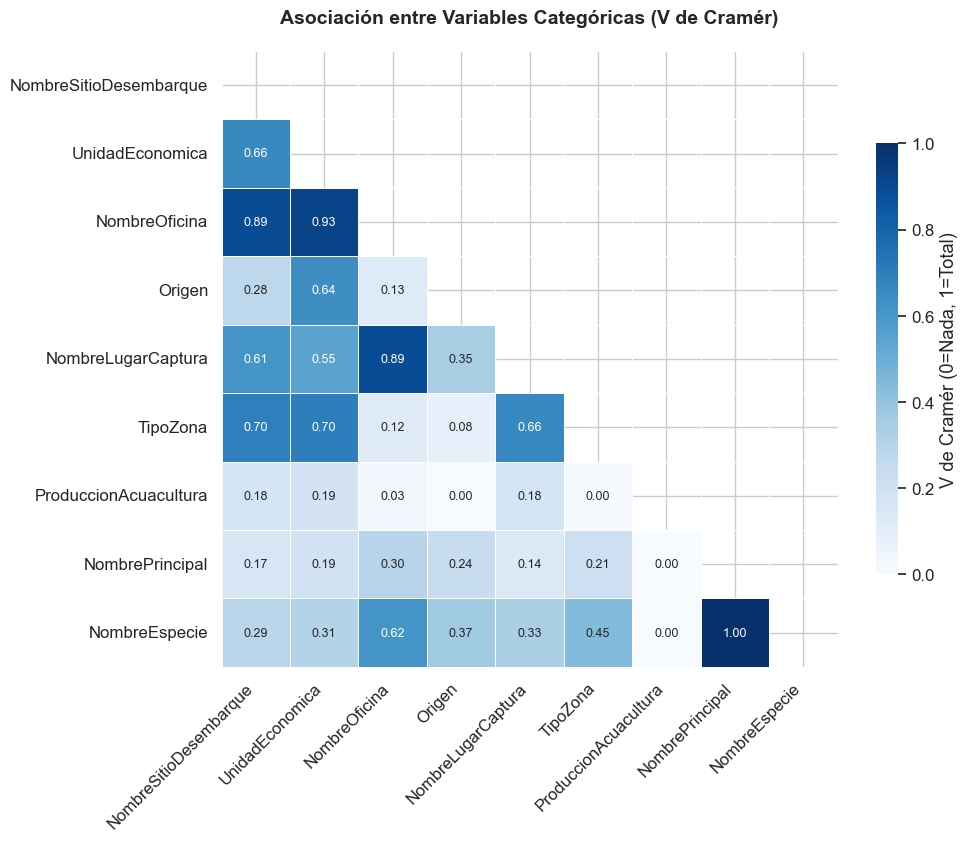


--- ⚠️ Diagnóstico de Redundancia Estructural (> 0.90) ---


,Variable A,Variable B,Asociación (V)
0,NombreOficina,UnidadEconomica,0.9280
1,NombreEspecie,NombrePrincipal,0.9984


-> Sugerencia: Estas variables contienen prácticamente la misma información (ej. Clave vs Nombre).


In [10]:
# Definición robusta de V de Cramér
def cramers_v(x, y):
    """Calcula la fuerza de asociación entre dos categóricos (0 a 1)."""
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.shape[0] == 0 or confusion_matrix.shape[1] == 0:
        return 0
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Corrección de Bias para resultados más precisos
    with np.errstate(divide='ignore', invalid='ignore'):
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        if min((kcorr-1), (rcorr-1)) == 0:
            return 0
        return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 1. Selección de Variables
df_cat = df.select_dtypes(include=['category', 'object'])
cols_cat = df_cat.columns.tolist()

if len(cols_cat) > 1:
    print(f"⏳ Calculando matriz de asociación para {len(cols_cat)} variables categóricas...")
    assoc_matrix = pd.DataFrame(index=cols_cat, columns=cols_cat)

    # 2. Cálculo de la Matriz (Iteración)
    for i in range(len(cols_cat)):
        for j in range(i + 1):
            col1, col2 = cols_cat[i], cols_cat[j]
            if i == j:
                val = 1.0
            else:
                val = cramers_v(df[col1], df[col2])
            
            # Llenado simétrico
            assoc_matrix.loc[col1, col2] = val
            assoc_matrix.loc[col2, col1] = val

    assoc_matrix = assoc_matrix.astype(float)

    # 3. Visualización (Heatmap Estético)
    plt.figure(figsize=(10, 8))
    
    # Máscara triangular
    mask = np.triu(np.ones_like(assoc_matrix, dtype=bool))
    
    # Paleta secuencial (Azules o Verdes) - Usamos 'Blues' para diferenciar de Pearson
    heatmap = sns.heatmap(
        assoc_matrix, 
        mask=mask, 
        annot=True, 
        fmt=".2f", 
        cmap='Blues', 
        vmin=0, 
        vmax=1,
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .7, "label": "V de Cramér (0=Nada, 1=Total)"},
        annot_kws={"size": 9}
    )
    
    heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, horizontalalignment='right')
    plt.title('Asociación entre Variables Categóricas (V de Cramér)', fontsize=14, fontweight='bold', pad=20)
    plt.show()

    # 4. Diagnóstico de Redundancia (> 0.90) con Tabla Estilizada
    print("\n--- ⚠️ Diagnóstico de Redundancia Estructural (> 0.90) ---")
    
    criticos = []
    for i in range(len(cols_cat)):
        for j in range(i):
            val = assoc_matrix.iloc[i, j]
            if val > 0.90:
                col_i = cols_cat[i]
                col_j = cols_cat[j]
                criticos.append({
                    'Variable A': col_i,
                    'Variable B': col_j,
                    'Asociación (V)': val
                })

    if criticos:
        df_criticos = pd.DataFrame(criticos)
        # Mostramos tabla estilizada en rojos
        display(
            df_criticos.style.background_gradient(subset=['Asociación (V)'], cmap='Reds', vmin=0.9, vmax=1)
            .format({'Asociación (V)': "{:.4f}"})
            .set_caption("Pares categóricos redundantes (Información duplicada)")
        )
        print("-> Sugerencia: Estas variables contienen prácticamente la misma información (ej. Clave vs Nombre).")
    else:
        print("✅ No se detectaron redundancias críticas entre categorías.")

else:
    print("ℹ️ No hay suficientes variables categóricas para este análisis.")

## Detección de Multicolinealidad: Factor de Inflación de Varianza (VIF)

Esta celda ejecuta un análisis avanzado para detectar redundancia entre variables predictoras numéricas:

**Diagnóstico Previo:**
En el análisis de VIF anterior, la variable `Anho` presentó un valor de **12.14**, superando el umbral recomendado de 10. Esto indica **multicolinealidad**, causada principalmente por la magnitud de los valores (ej. 2010, 2011...) que actúan casi como una constante matemática en relación con su varianza.

**Solución Aplicada: Centrado de Variable**
Para corregir esto sin perder la información de la tendencia temporal, aplicaremos una transformación de **centrado**:
$$Anho\_Centrado = Anho - Anho_{min}$$

**¿Por qué es crítico este paso para los modelos seleccionados?**
1.  **Regresión Polinomial (Estabilidad Numérica):** Este modelo elevará las variables al cuadrado o al cubo. Calcular $(2023)^3$ genera números masivos que causan inestabilidad o desbordamiento. Calcular $(13)^3$ es perfectamente manejable.
2.  **SVM (Sensibilidad de Escala):** Las Máquinas de Soporte Vectorial dependen de distancias geométricas. Reducir la escala de miles (2000s) a unidades (0-15) facilita drásticamente que el modelo converja y encuentre el margen óptimo.
3.  **Reducción del VIF:** Al centrar la variable, eliminamos la correlación estructural con el intercepto, bajando el VIF a niveles saludables (generalmente < 5).

1.  **Cálculo del VIF:** El *Variance Inflation Factor* cuantifica cuánto aumenta la varianza de un coeficiente de regresión estimado debido a la colinealidad.
2.  **Criterio de Evaluación:**
    * **VIF $\approx$ 1:** No hay correlación.
    * **1 < VIF < 5:** Correlación moderada (generalmente aceptable).
    * **VIF > 10:** Multicolinealidad severa. Indica que la variable puede ser predicha linealmente por otras variables con gran precisión, lo que inestabiliza los modelos de regresión.
3.  **Diagnóstico:** El script alerta automáticamente sobre las variables que superan el umbral de 10, sugiriendo candidatos para eliminación en la selección de características.

In [11]:
# --- PASO 1: Crear la variable centrada y ELIMINAR la original ---

# Verificamos si 'Anho' existe para evitar errores si corres la celda varias veces
if 'Anho' in df.columns:
    min_anho = df['Anho'].min()
    df['Anho_Centrado'] = df['Anho'] - min_anho
    print(f"✅ Variable 'Anho_Centrado' creada correctamente (Año base: {min_anho}).")
    
else:
    print("ℹ️ La columna 'Anho' ya fue eliminada o no existe.")

# --- PASO 2: Recalcular VIF para verificar la mejora ---

# Detectamos numéricas (Ahora incluirá 'Anho_Centrado' automáticamente y ya no tendrá 'Anho')
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Lista de columnas a EXCLUIR del cálculo VIF 
# NOTA: Ya quitamos 'Anho' de esta lista porque la borramos del DF arriba.
features_vif = [c for c in cols_numericas]

print(f"Variables analizadas para VIF: {features_vif}")

# Preparamos la matriz para VIF (eliminando nulos por seguridad)
X_vif = df[features_vif].dropna()

# Calculamos VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                   for i in range(len(X_vif.columns))]

# Mostramos el resultado ordenado
display(vif_data.sort_values(by="VIF", ascending=False))

✅ Variable 'Anho_Centrado' creada correctamente (Año base: 2010).
Variables analizadas para VIF: ['NumeroEmbarcaciones', 'Mes', 'Anho', 'DiasEfectivos', 'PesoDesembarcadoKg', 'PesoVivoKg', 'Precio', 'Valor', 'Anho_Centrado']


,Variable,VIF
4,PesoDesembarcadoKg,525.363805
5,PesoVivoKg,504.642882
2,Anho,15.655470
8,Anho_Centrado,5.203908
7,Valor,3.211478
6,Precio,1.602091
3,DiasEfectivos,1.178928
0,NumeroEmbarcaciones,1.073382
1,Mes,1.006830


## Prevención de Fuga de Datos y Reevaluación de Colinealidad

Esta celda refina el conjunto de datos para garantizar la validez del modelo predictivo:

1.  **Eliminación por *Data Leakage*:** Se descartan variables como `PesoDesembarcadoKg` y `Valor`. Estas variables suelen ser transformaciones directas de la variable objetivo (`PesoVivoKg`) o datos que se conocen *después* del evento de captura, lo que falsearía métricas de rendimiento del modelo (predicción perfecta irreal).
2.  **Aislamiento de Predictores ($X$):** Se separa la variable objetivo ($Y$) de las variables independientes.
3.  **VIF Definitivo:** Se recalcula el Factor de Inflación de Varianza **exclusivamente sobre los predictores**. Esto es crucial para diagnosticar si existe redundancia real entre las características de entrada (input features) sin la distorsión que generaría incluir el target en el cálculo.

In [12]:
# 1. Mitigación de Fuga de Datos (Data Leakage)
# Se eliminan variables altamente correlacionadas con el target o que no estarían disponibles en tiempo de inferencia.
cols_leakage = ['PesoDesembarcadoKg', 'Valor']
cols_a_borrar = [c for c in cols_leakage if c in df.columns]

if cols_a_borrar:
    df.drop(columns=cols_a_borrar, inplace=True)
    print(f"🗑️ Se eliminaron variables de riesgo de Leakage: {cols_a_borrar}")
else:
    print("ℹ️ No se encontraron variables de leakage (ya fueron eliminadas).")

# 2. Definición del Espacio de Predictores (X)
# El VIF analiza la relación entre variables independientes, por lo que se excluye la variable objetivo (Target).
target = 'PesoVivoKg'
predictors = df.select_dtypes(include=['number']).columns.tolist()

if target in predictors:
    predictors.remove(target)

# 3. Recálculo del Factor de Inflación de Varianza (VIF)
if len(predictors) > 1:
    print(f"\n--- Análisis VIF en {len(predictors)} Predictores (Sin Target) ---")
    df_predictors = df[predictors].dropna()

    vif_data = pd.DataFrame()
    vif_data["Variable"] = df_predictors.columns
    vif_data["VIF"] = [variance_inflation_factor(df_predictors.values, i) 
                       for i in range(df_predictors.shape[1])]

    # Visualización ordenada
    print(vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True))
else:
    print("⚠️ Número insuficiente de predictores numéricos para calcular VIF.")

🗑️ Se eliminaron variables de riesgo de Leakage: ['PesoDesembarcadoKg', 'Valor']

--- Análisis VIF en 6 Predictores (Sin Target) ---
              Variable        VIF
0                 Anho  14.012106
1        Anho_Centrado   5.148775
2               Precio   1.100127
3  NumeroEmbarcaciones   1.058211
4        DiasEfectivos   1.024381
5                  Mes   1.006260


## Refinamiento de Características y Definición del Target

Esta celda finaliza la preparación de los datos aplicando técnicas de reducción de complejidad:

1.  **Eliminación de Redundancia Taxonómica:** Evalúa la cardinalidad entre `NombreEspecie` y `NombrePrincipal`. Se elimina la variable con mayor número de categorías únicas (generalmente la más específica) para favorecer la generalización del modelo y evitar la fragmentación excesiva de la información.
2.  **Agrupamiento de Categorías Raras (*Rare Label Encoding*):**
    * Itera sobre todas las variables categóricas.
    * Identifica categorías con una frecuencia inferior a **20 ocurrencias**.
    * Agrupa estos valores bajo la etiqueta genérica **"OTROS"**.
    * **Objetivo:** Reducir la dimensionalidad (número de columnas resultantes tras un futuro *One-Hot Encoding*) y mitigar el ruido estadístico generado por clases con soporte muestral insuficiente.
3.  **Auditoría Final:** Define explícitamente la variable dependiente ($Y$) y el vector de características ($X$), verificando las dimensiones finales del conjunto de datos listo para el modelado.

In [13]:
# 1. Resolución de Redundancia Taxonómica (Selección de Feature)
# Se compara la granularidad entre 'NombreEspecie' y 'NombrePrincipal'.
# Se conserva la variable más general (menor cardinalidad) para reducir ruido.
if 'NombreEspecie' in df.columns and 'NombrePrincipal' in df.columns:
    n_especies = df['NombreEspecie'].nunique()
    n_principal = df['NombrePrincipal'].nunique()

    print(f"--- Análisis de Granularidad Taxonómica ---")
    print(f" - NombreEspecie:   {n_especies} categorías únicas")
    print(f" - NombrePrincipal: {n_principal} categorías únicas")

    if n_principal <= n_especies:
        col_a_borrar = 'NombreEspecie'
        print("✅ Decisión: Se conserva 'NombrePrincipal' (Mayor generalidad).")
    else:
        col_a_borrar = 'NombrePrincipal'
        print("⚠️ Decisión: Se conserva 'NombreEspecie' (Menor cardinalidad detectada).")

    df.drop(columns=[col_a_borrar], inplace=True)
    print(f"🗑️ Eliminada: {col_a_borrar}")

# 2. Ingeniería de Características: Tratamiento de Clases Raras
# Agrupamiento de categorías con baja frecuencia (Rare Labels) bajo la etiqueta 'OTROS'.
# Esto previene el sobreajuste y reduce la dimensionalidad tras el One-Hot Encoding.
UMBRAL_FRECUENCIA = 20
cols_cat = df.select_dtypes(include=['category', 'object']).columns.tolist()

if cols_cat:
    print(f"\n--- Agrupamiento de Categorías Raras (Umbral: < {UMBRAL_FRECUENCIA}) ---")
    for col in cols_cat:
        conteo = df[col].value_counts()
        clases_frecuentes = conteo[conteo >= UMBRAL_FRECUENCIA].index
        
        # Si existen clases por debajo del umbral
        if len(clases_frecuentes) < len(conteo):
            # Manipulación como objeto para reemplazo seguro
            serie_temp = df[col].astype(object)
            mask_raros = ~serie_temp.isin(clases_frecuentes)
            n_afectados = mask_raros.sum()
            
            serie_temp[mask_raros] = 'OTROS'
            df[col] = serie_temp.astype('category')
            
            print(f"> {col}: Reducido de {len(conteo)} a {df[col].nunique()} categorías. ({n_afectados} registros asignados a 'OTROS')")
        else:
            print(f"> {col}: Distribución robusta. No se requiere agrupación.")

# 3. Definición Final del Espacio de Modelado
target_var = 'PesoVivoKg'
predictor_vars = [col for col in df.columns if col != target_var]

print("\n--- ✅ ESTADO FINAL DEL DATASET ---")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"🎯 Variable Objetivo (Target): {target_var}")
print(f"📦 Predictores (Features):     {len(predictor_vars)} variables")
print(f"   Lista: {predictor_vars}")

--- Análisis de Granularidad Taxonómica ---
 - NombreEspecie:   203 categorías únicas
 - NombrePrincipal: 36 categorías únicas
✅ Decisión: Se conserva 'NombrePrincipal' (Mayor generalidad).
🗑️ Eliminada: NombreEspecie

--- Agrupamiento de Categorías Raras (Umbral: < 20) ---
> NombreSitioDesembarque: Reducido de 75 a 50 categorías. (135 registros asignados a 'OTROS')
> UnidadEconomica: Reducido de 75 a 58 categorías. (77 registros asignados a 'OTROS')
> NombreOficina: Reducido de 4 a 4 categorías. (4 registros asignados a 'OTROS')
> Origen: Distribución robusta. No se requiere agrupación.
> NombreLugarCaptura: Reducido de 50 a 31 categorías. (78 registros asignados a 'OTROS')
> TipoZona: Distribución robusta. No se requiere agrupación.
> ProduccionAcuacultura: Reducido de 2 a 2 categorías. (10 registros asignados a 'OTROS')
> NombrePrincipal: Reducido de 36 a 26 categorías. (61 registros asignados a 'OTROS')

--- ✅ ESTADO FINAL DEL DATASET ---
Dimensiones: 52688 filas x 15 columnas
🎯 Va

## Dashboard Gráfico: Diagnóstico Multidimensional

Esta celda genera un panel de visualización integral (GridSpec 3x3) para evaluar el estado final del conjunto de datos antes del modelado:

1.  **Fila Superior (Distribuciones Univariadas):** Muestra *Boxplots* de variables operativas clave (`NumeroEmbarcaciones`, `DiasEfectivos`) y económicas (`Precio`), facilitando la detección visual de valores atípicos y rangos intercuartílicos.
2.  **Fila Media (Estructura y Relación):**
    * **Balance de Clases:** *Countplot* de las 10 especies principales para verificar si el agrupamiento de "OTROS" fue efectivo y visualizar las clases dominantes.
    * **Relación Bivariada:** *Scatterplot* (Precio vs. PesoVivoKg) con escala logarítmica en el eje Y, útil para identificar patrones de dispersión o elasticidad precio-producción.
3.  **Fila Inferior (Segmentación Espacial):** Analiza la distribución de la variable objetivo (`PesoVivoKg`) desglosada por `NombreOficina`. Se utiliza escala logarítmica para manejar la alta varianza de la biomasa y comparar medianas de captura entre distintas zonas geográficas.

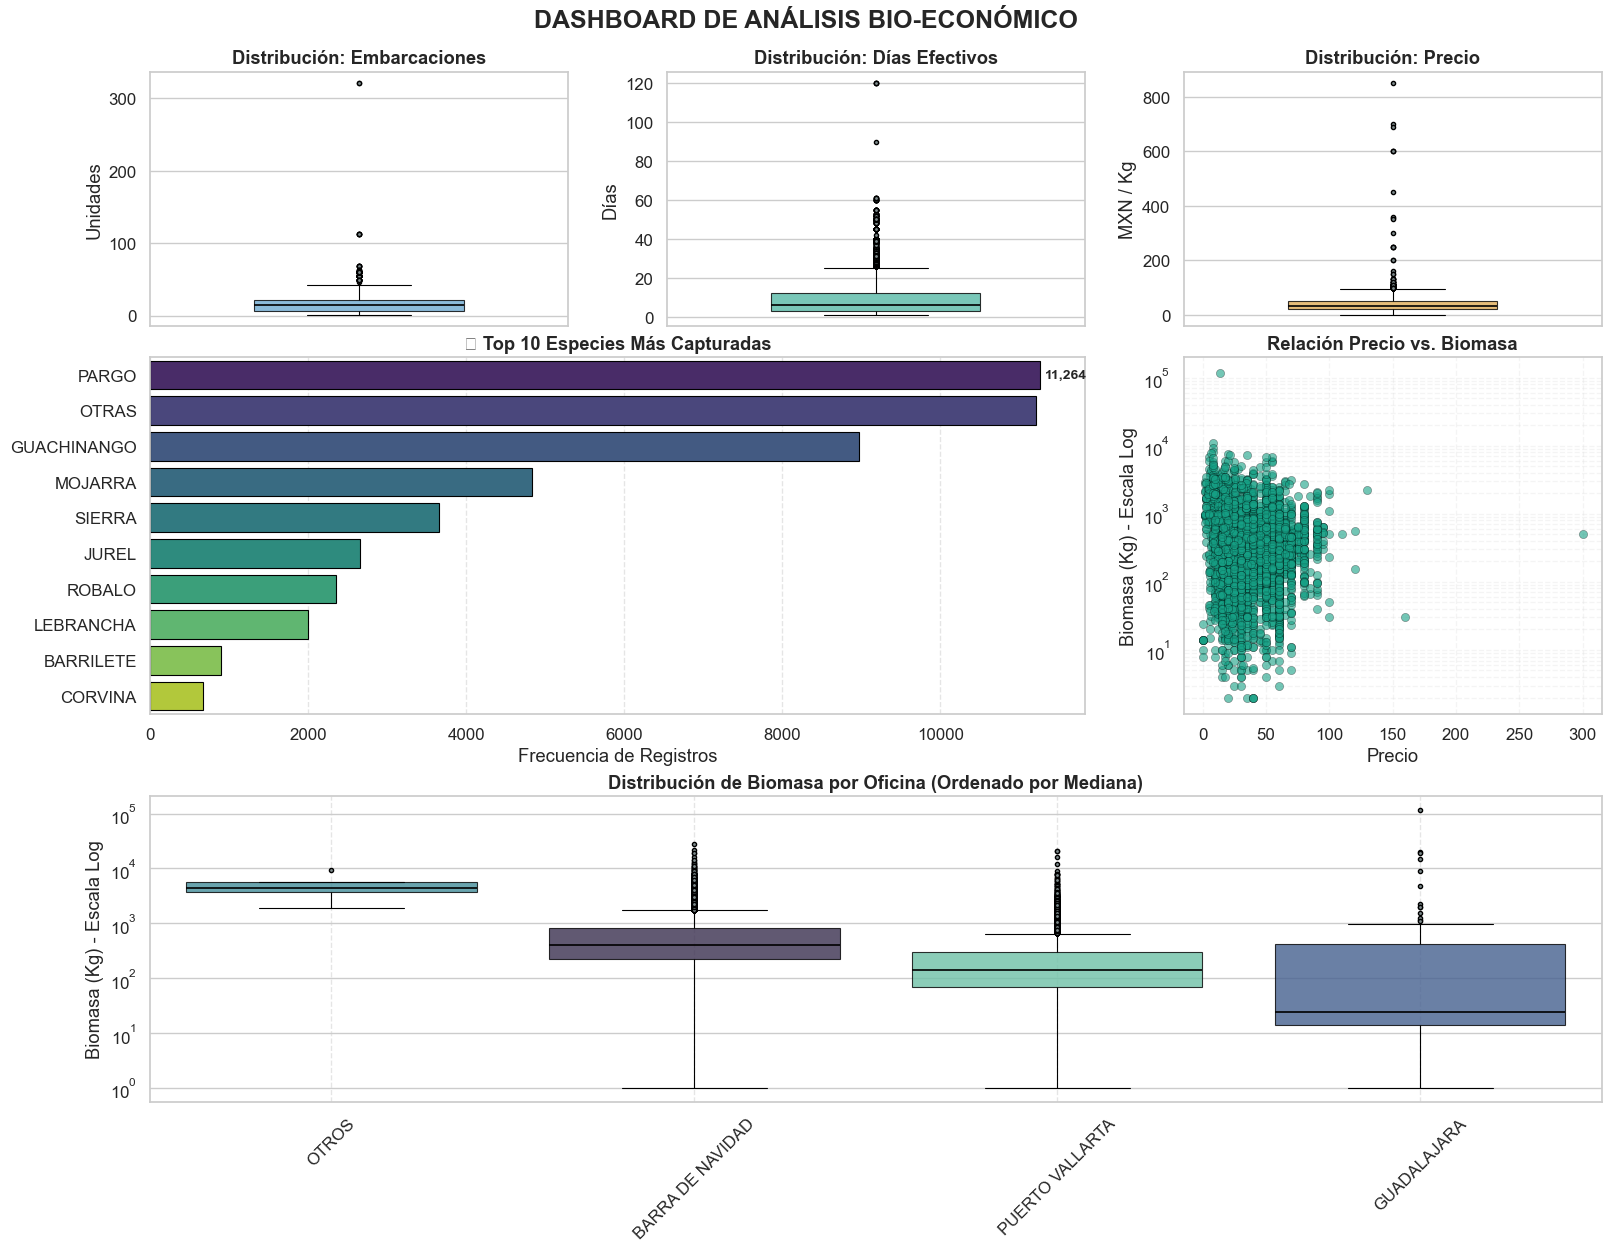

In [14]:
# Validación de columnas
cols_disponibles = df.columns.tolist()
tiene_precio = 'Precio' in cols_disponibles
tiene_oficina = 'NombreOficina' in cols_disponibles
tiene_peso = 'PesoVivoKg' in cols_disponibles

# Propiedades visuales para asegurar que las cajas se vean bien (bordes negros)
props_box = {
    'boxprops': {'edgecolor': 'black', 'linewidth': 0.8, 'alpha': 0.8},
    'medianprops': {'color': 'black', 'linewidth': 1.2},
    'whiskerprops': {'color': 'black', 'linewidth': 0.8},
    'capprops': {'color': 'black', 'linewidth': 0.8},
    'flierprops': {'marker': 'o', 'markerfacecolor': '#7f8c8d', 'markeredgecolor': 'black', 'markersize': 3}
}

# --- 2. CREACIÓN DEL LAYOUT ---
fig = plt.figure(figsize=(16, 12), constrained_layout=True)
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1.4, 1.2]) # Fila central un poco más alta

fig.suptitle("DASHBOARD DE ANÁLISIS BIO-ECONÓMICO", fontsize=18, fontweight='bold', y=1.03)

# --- FILA 1: DISTRIBUCIONES (BOXPLOTS) ---

# 1.1 Embarcaciones
ax1 = fig.add_subplot(gs[0, 0])
if 'NumeroEmbarcaciones' in cols_disponibles:
    sns.boxplot(y=df['NumeroEmbarcaciones'], ax=ax1, color="#5DADE2", width=0.5, **props_box)
    ax1.set_title("Distribución: Embarcaciones", fontweight='bold')
    ax1.set_ylabel('Unidades')

# 1.2 Días Efectivos
ax2 = fig.add_subplot(gs[0, 1])
if 'DiasEfectivos' in cols_disponibles:
    sns.boxplot(y=df['DiasEfectivos'], ax=ax2, color="#48C9B0", width=0.5, **props_box)
    ax2.set_title("Distribución: Días Efectivos", fontweight='bold')
    ax2.set_ylabel('Días')

# 1.3 Precio
ax3 = fig.add_subplot(gs[0, 2])
if tiene_precio:
    sns.boxplot(y=df['Precio'], ax=ax3, color="#F5B041", width=0.5, **props_box)
    ax3.set_title("Distribución: Precio", fontweight='bold')
    ax3.set_ylabel('MXN / Kg')
else:
    ax3.text(0.5, 0.5, 'Sin datos de Precio', ha='center', va='center')
    ax3.axis('off')


# --- FILA 2: EL GRÁFICO PROBLEMÁTICO (ARREGLADO) ---

# 2.1 Top 10 Especies
ax4 = fig.add_subplot(gs[1, :2])
if 'NombrePrincipal' in cols_disponibles:
    # A) Obtenemos el conteo
    conteo = df['NombrePrincipal'].value_counts().head(10)
    
    # B) TRUCO CLAVE: Convertimos a listas de Python puras
    # Esto elimina cualquier metadato de "Categoría" que esté ensuciando el gráfico
    y_labels = conteo.index.astype(str).tolist()
    x_values = conteo.values
    
    # C) Graficamos usando las listas
    bar_plot = sns.barplot(
        x=x_values,
        y=y_labels,
        ax=ax4,
        palette="viridis",
        hue=y_labels,    # Requerido por Seaborn nuevo
        legend=False,
        edgecolor="black", # Borde negro para que se vea sí o sí
        linewidth=0.8
    )
    
    # D) Etiquetas numéricas
    ax4.bar_label(bar_plot.containers[0], fmt='{:,.0f}', padding=3, fontsize=10, fontweight='bold')
    
    ax4.set_title("🏆 Top 10 Especies Más Capturadas", fontweight='bold')
    ax4.set_xlabel('Frecuencia de Registros')
    ax4.grid(axis='x', linestyle='--', alpha=0.5)


# 2.2 Scatter Precio vs Biomasa
ax5 = fig.add_subplot(gs[1, 2])
if tiene_precio and tiene_peso:
    # Muestreo para no saturar
    data_sample = df.sample(5000, random_state=42) if len(df) > 5000 else df
    
    sns.scatterplot(
        x='Precio', y='PesoVivoKg', data=data_sample, ax=ax5, 
        alpha=0.6, color="#16A085", 
        edgecolor='black', linewidth=0.3, s=35
    )
    
    ax5.set_title("Relación Precio vs. Biomasa", fontweight='bold')
    ax5.set_yscale('log')
    ax5.set_ylabel('Biomasa (Kg) - Escala Log')
    ax5.grid(True, which="both", ls="--", alpha=0.2)

# --- FILA 3: BIOMASA POR OFICINA ---

# 3.1 Biomasa por Oficina
ax6 = fig.add_subplot(gs[2, :])
if tiene_oficina and tiene_peso:
    # Ordenamos las oficinas por su mediana para que se vea escalonado
    order_oficina = df.groupby('NombreOficina')['PesoVivoKg'].median().sort_values(ascending=False).index
    
    sns.boxplot(
        x='NombreOficina', y='PesoVivoKg', data=df, ax=ax6, 
        palette="mako", order=order_oficina, hue='NombreOficina', legend=False,
        **props_box
    )
    
    ax6.set_title("Distribución de Biomasa por Oficina (Ordenado por Mediana)", fontweight='bold')
    ax6.set_yscale('log')
    ax6.set_ylabel('Biomasa (Kg) - Escala Log')
    ax6.set_xlabel('')
    ax6.tick_params(axis='x', rotation=45) # Rotación para leer los nombres
    ax6.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

## Exportación y Persistencia del Dataset Limpio

Esta celda finaliza el flujo de preprocesamiento guardando el DataFrame depurado (`df`) en el disco local:

1.  **Gestión de Directorios:** Verifica la existencia de la carpeta destino y la crea automáticamente si es necesario, evitando errores de ruta no encontrada.
2.  **Serialización CSV:** Exporta los datos a formato `.csv` utilizando codificación `UTF-8` para preservar caracteres especiales (tildes, ñ) y excluyendo el índice numérico de Pandas para mantener el archivo limpio.
3.  **Hito del Proyecto:** Confirma que los datos están listos para ser consumidos por los algoritmos de Machine Learning en la siguiente etapa del proyecto.

In [15]:
# Definición de ruta de salida
output_path = r'D:\WORKSPACE\CUGDL\IACD\2025B\PJ_ESCAMA_MARINA\Data_Frames\pesca_jalisco_limpio.csv'

print(f"Iniciando exportación de datos...")

try:
    # Verificación y creación del directorio si no existe
    output_dir = os.path.dirname(output_path)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"📂 Directorio creado: {output_dir}")

    # Exportación a CSV
    # index=False: No guardar el índice numérico de Pandas
    # encoding='utf-8': Estándar para caracteres especiales
    df_clean = df.copy()
    df_clean.to_csv(output_path, index=False, encoding='utf-8')
    
    print(f"✅ Archivo guardado exitosamente.")
    print(f"   - Ruta: {output_path}")
    print(f"   - Dimensiones finales: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")
    print("🚀 Dataset listo para la fase de Modelado.")

except PermissionError:
    print(f"❌ Error: Permiso denegado. Cierra el archivo si lo tienes abierto en Excel.")
except Exception as e:
    print(f"❌ Error crítico al guardar el archivo: {e}")

Iniciando exportación de datos...
✅ Archivo guardado exitosamente.
   - Ruta: D:\WORKSPACE\CUGDL\IACD\2025B\PJ_ESCAMA_MARINA\Data_Frames\pesca_jalisco_limpio.csv
   - Dimensiones finales: 52688 filas x 15 columnas
🚀 Dataset listo para la fase de Modelado.


# 4. Preparación para modelado

## Checkpoint

In [16]:
# Se crea copia de seguridas para el EDA Ananítico e Ingeniería de Características.
df = df_clean.copy()

print(f"✅ Checkpoint Exitoso.")
print(f"- Dataset limpio preservado en 'df_clean'. Copia de trabajo asignada a 'df'.")

✅ Checkpoint Exitoso.
- Dataset limpio preservado en 'df_clean'. Copia de trabajo asignada a 'df'.


## Auditoría de Registros Duplicados (Diagnóstico)

En esta sección se cuantifica la redundancia exacta dentro del dataset **sin modificar ni eliminar** ningún registro. El objetivo es dimensionar la frecuencia de los "Duplicados Naturales".

1.  **Agrupación Estricta:** Se identifican filas que son idénticas en **todas** sus columnas.
    * *Nota:* Se utiliza `dropna=False` para considerar también los valores vacíos (`NaN`) como criterios de igualdad.
2.  **Distinción de Métricas:**
    * **Exceso (Filas Redundantes):** El volumen total de registros que son "copias extra".
    * **Patrones Únicos:** La cantidad de casos distintos que se están repitiendo (ej. cuántas combinaciones únicas de *Barco + Especie + Sitio* tienen duplicados).
3.  **Visualización:** Se genera un ranking estilizado con los **15 registros más frecuentes** para inspeccionar qué eventos de pesca son los más recurrentes en la base de datos.

In [17]:
# --- REPORTE DE DUPLICADOS EXACTOS ---

# 1. Agrupación y Conteo
# value_counts(dropna=False) es vital: agrupa filas idénticas incluso si tienen campos vacíos (NaN)
# Esto crea una tabla donde cada fila es única y tiene una columna 'Repeticiones'
conteo_global = df.value_counts(dropna=False).reset_index(name='Repeticiones')

# 2. Filtramos solo los registros que se repiten (Frecuencia > 1)
df_duplicados = conteo_global[conteo_global['Repeticiones'] > 1]

# 3. Cálculo de Métricas
n_total_filas = len(df)
n_exceso = df.duplicated(keep='first').sum() # Cantidad de filas redundantes (las "copias")
n_patrones = len(df_duplicados) # Cantidad de "casos únicos" que tienen copias

pct_duplicados = (n_exceso / n_total_filas) * 100

# 4. Impresión del Diagnóstico
print(f"--- 🔎 Diagnóstico de Identidad ---")
print(f"Total de filas en el dataset:   {n_total_filas}")
print(f"Filas redundantes (Exceso):     {n_exceso} ({pct_duplicados:.2f}%)")
print(f"Patrones únicos repetidos:      {n_patrones}")
print("-" * 50)

if n_exceso > 0:
    print(f"\n📊 TOP 15 REGISTROS MÁS REPETIDOS:")
    print("(La columna 'Repeticiones' indica cuántas veces aparece esta fila idéntica)")
    
    # Mostramos la tabla estilizada con barra de color en las repeticiones
    display(
        df_duplicados.head(15).style
        .background_gradient(subset=['Repeticiones'], cmap='Reds')
        .format({'Repeticiones': "{:.0f}"})
    )
    
    print(f"\n💡 Interpretación:")
    print(f"• Tienes {n_patrones} combinaciones únicas de datos que se repiten.")
    print(f"• En total, esas repeticiones generan {n_exceso} filas extra en tu base de datos.")
else:
    print("✅ ¡Felicidades! No hay ninguna fila idéntica a otra en todo el dataset.")

--- 🔎 Diagnóstico de Identidad ---
Total de filas en el dataset:   52688
Filas redundantes (Exceso):     1067 (2.03%)
Patrones únicos repetidos:      939
--------------------------------------------------

📊 TOP 15 REGISTROS MÁS REPETIDOS:
(La columna 'Repeticiones' indica cuántas veces aparece esta fila idéntica)


,NombreSitioDesembarque,UnidadEconomica,NombreOficina,Origen,NombreLugarCaptura,NumeroEmbarcaciones,Mes,Anho,DiasEfectivos,TipoZona,ProduccionAcuacultura,NombrePrincipal,PesoVivoKg,Precio,Anho_Centrado,Repeticiones
0,CORRALES,"SCPP AGRO-OCEANICOS DE CABO CORRRIENTES, S.C. DE R.L.",PUERTO VALLARTA,OFICINA,BAHIA EL CORRAL,6,10,2011,3,BAHIA,NO,OTRAS,175.000000,25.000000,1,4
1,CORRALES,"SCPP AGRO-OCEANICOS DE CABO CORRRIENTES, S.C. DE R.L.",PUERTO VALLARTA,OFICINA,BAHIA EL CORRAL,6,8,2011,3,LITORAL,NO,PARGO,250.000000,45.000000,1,4
2,CORRALES,"SCPP AGRO-OCEANICOS DE CABO CORRRIENTES, S.C. DE R.L.",PUERTO VALLARTA,OFICINA,BAHIA BANDERAS,6,9,2018,2,BAHIA,NO,MOJARRA,30.000000,23.000000,8,4
3,PRESA RAMON CORONA,SCPP TRIGO MIL SC DE RL,GUADALAJARA,EN LINEA,PRESA RAMON CORONA,1,3,2020,7,LITORAL,NO,CARPA,14.000000,0.000000,10,4
4,BAHIA DE TEHUAMIXTLE,"S.C.P.P. TEHUAMIXTLE, S.C. DE R.L.",PUERTO VALLARTA,OFICINA,OCEANO PACIFICO,20,6,2016,7,LITORAL,NO,PARGO,15.000000,35.000000,6,4
5,CORRALES,"SCPP AGRO-OCEANICOS DE CABO CORRRIENTES, S.C. DE R.L.",PUERTO VALLARTA,OFICINA,BAHIA BANDERAS,6,7,2017,2,BAHIA,NO,BARRILETE,100.000000,15.000000,7,4
6,CORRALES,"SCPP AGRO-OCEANICOS DE CABO CORRRIENTES, S.C. DE R.L.",PUERTO VALLARTA,OFICINA,BAHIA EL CORRAL,6,10,2011,3,BAHIA,NO,MOJARRA,150.000000,30.000000,1,4
7,BAHIA DE YELAPA,S.C.P.P. LANGOSTA DE YELAPA SC. DE R.L.,PUERTO VALLARTA,OFICINA,BAHIA BANDERAS,14,2,2012,3,BAHIA,NO,OTRAS,100.000000,20.000000,2,4
8,CORRALES,"SCPP AGRO-OCEANICOS DE CABO CORRRIENTES, S.C. DE R.L.",PUERTO VALLARTA,OFICINA,BAHIA EL CORRAL,6,8,2011,3,LITORAL,NO,OTRAS,175.000000,35.000000,1,4
9,CORRALES,"SCPP AGRO-OCEANICOS DE CABO CORRRIENTES, S.C. DE R.L.",PUERTO VALLARTA,OFICINA,BAHIA EL CORRAL,6,10,2011,3,BAHIA,NO,OTRAS,250.000000,35.000000,1,4



💡 Interpretación:
• Tienes 939 combinaciones únicas de datos que se repiten.
• En total, esas repeticiones generan 1067 filas extra en tu base de datos.


## Agrupación Estratégica de Datos (Nivel Mensual-Sitio)

Para mejorar la capacidad predictiva de los modelos y reducir el "ruido" de los registros individuales (viajes de pesca diarios con alta variabilidad), transformamos la estructura del dataset.

Pasamos de un nivel **transaccional** (cada fila es un viaje) a un nivel **agregado** (cada fila es el resumen mensual de una pesquería en un sitio específico).

### Lógica de Agrupación:
Utilizamos 4 claves para definir un registro único:
1.  **`Anho` y `Mes`:** Para capturar la estacionalidad y tendencias temporales.
2.  **`NombrePrincipal`:** Para distinguir el comportamiento biológico por especie.
3.  **`NombreSitioDesembarque`:** Para diferenciar la productividad geográfica (cada sitio tiene capacidades distintas).

### Reglas de Matemáticas (Aggregations):
* **Suma (`sum`):** Para `PesoVivoKg`, `DiasEfectivos` y `NumeroEmbarcaciones`. Nos interesa el volumen total acumulado en el mes.
* **Promedio (`mean`):** Para `Precio`. No tiene sentido sumar precios; nos interesa el valor de mercado representativo de ese mes.

**Resultado:** Un dataset más compacto y estable, donde el objetivo es predecir la biomasa total mensual por sitio y especie.

In [18]:
# --- AGRUPACIÓN CORREGIDA (SIN EXPLOSIÓN DE FILAS) ---

# 1. Columnas clave
columnas_clave = ['Anho', 'Mes', 'NombrePrincipal', 'NombreSitioDesembarque']

print(f"Filas ANTES de agrupar: {df.shape[0]}")

# 2. Agrupación con observed=True
# Esto evita que Pandas cree combinaciones fantasmas de especies/lugares que no existen
df_agrupado = df.groupby(columnas_clave, observed=True).agg({
    'PesoVivoKg': 'sum',
    'DiasEfectivos': 'sum',
    'NumeroEmbarcaciones': 'sum',
    'Precio': 'mean'
}).reset_index()

# 3. Verificación
print(f"Filas DESPUÉS de agrupar: {df_agrupado.shape[0]}")

if df_agrupado.shape[0] > df.shape[0]:
    print("❌ ALERTA: Las filas aumentaron. Algo sigue mal.")
else:
    print("✅ ÉXITO: Las filas se redujeron correctamente.")
    display(df_agrupado.head())

    # 4. Actualizamos
    df = df_agrupado

Filas ANTES de agrupar: 52688
Filas DESPUÉS de agrupar: 15464
✅ ÉXITO: Las filas se redujeron correctamente.


,Anho,Mes,NombrePrincipal,NombreSitioDesembarque,PesoVivoKg,DiasEfectivos,NumeroEmbarcaciones,Precio
0,2010,1,ATUN,BOCA DE TOMATLAN,760.0,6,2,10.0
1,2010,1,BARRILETE,BOCA DE TOMATLAN,760.0,6,2,30.0
2,2010,1,BERRUGATA,EL CHAMBRE,400.0,3,1,30.0
3,2010,1,BERRUGATA,LAGUNA DE BARRA DE NAVIDAD,1327.0,26,1,8.0
4,2010,1,CORVINA,EL CHAMBRE,600.0,3,1,50.0


## Limpieza y Tratamiento de Valores Ausentes (NaN)

Tras la agrupación, es posible que se hayan generado valores vacíos (por ejemplo, promedios de precios inexistentes) o que el dataset original tuviera huecos. Los modelos matemáticos como SVM **no funcionan** si encuentran un solo valor `NaN` (Not a Number).

En este paso aplicamos una estrategia de limpieza **selectiva** para evitar errores de tipo de dato:

1.  **Imputación en Variables Numéricas:**
    * Identificamos las columnas de números (`Precio`, `DiasEfectivos`, etc.).
    * Rellenamos los huecos con **0**. *Asumimos que si no hay registro de embarcaciones o esfuerzo, el valor es nulo.*
    * *Nota Técnica:* Hacemos esto solo en las columnas numéricas para evitar errores al intentar insertar un "0" en columnas de texto categórico.

2.  **Limpieza de Variables Categóricas:**
    * Si falta el nombre de la `Especie` o el `Lugar`, eliminamos la fila completa.
    * *Razón:* No podemos inventar o imputar la especie; un dato sin etiqueta biológica o geográfica no sirve para entrenar el modelo.

3.  **Eliminación de Varianza Cero:**
    * Verificamos si alguna columna tiene el mismo valor en todas las filas (ej: todas son 0). Si es así, la eliminamos, ya que causaría errores matemáticos (división por cero) durante el escalado de datos.

In [19]:
# --- LIMPIEZA DE NANS (CORREGIDO Y SEGURO) ---

print("🔍 Limpiando valores vacíos de forma selectiva...")

# 1. Separamos mentalmente las columnas
columnas_numericas = df.select_dtypes(include=[np.number]).columns
columnas_texto = df.select_dtypes(exclude=[np.number]).columns

# 2. Rellenamos con 0 SOLO las columnas numéricas (Barcos, Días, etc.)
# Esto evita el error de "Cannot setitem on a Categorical"
df[columnas_numericas] = df[columnas_numericas].fillna(0)

# 3. Para las columnas de Texto (Especie, Zona...), si hay huecos, eliminamos la fila
# (No podemos inventar la especie si no está registrada)
filas_antes = df.shape[0]
df = df.dropna(subset=columnas_texto)
filas_despues = df.shape[0]

if filas_antes > filas_despues:
    print(f"⚠️ Se eliminaron {filas_antes - filas_despues} filas que no tenían Especie o Lugar registrado.")

# 4. Revisión de seguridad: Eliminar columnas con varianza 0
# (Columnas que tienen el mismo valor en todas las filas causan error al escalar)
# Recalculamos las numéricas por si alguna se volvió constante
columnas_numericas_actuales = df.select_dtypes(include=[np.number]).columns
var_cero = [col for col in columnas_numericas_actuales if df[col].std() == 0]

if var_cero:
    print(f"⚠️ Eliminando columnas constantes (Varianza 0): {var_cero}")
    df = df.drop(columns=var_cero)

print(f"\n✅ Datos totalmente limpios y listos. Filas finales: {df.shape[0]}")

🔍 Limpiando valores vacíos de forma selectiva...

✅ Datos totalmente limpios y listos. Filas finales: 15464


📊 Generando Reporte Descriptivo Completo...

--- Resumen Estadístico (.describe) ---


,PesoVivoKg,Precio,DiasEfectivos,NumeroEmbarcaciones
count,15464.00,15464.00,15464.00,15464.00
mean,1769.89,35.28,33.43,48.47
std,3500.73,20.64,45.94,63.12
min,1.00,0.00,1.00,1.00
25%,283.00,20.00,8.00,14.00
50%,670.00,30.00,21.00,28.00
75%,1740.00,50.00,36.00,63.00
max,115453.80,850.00,776.00,750.00


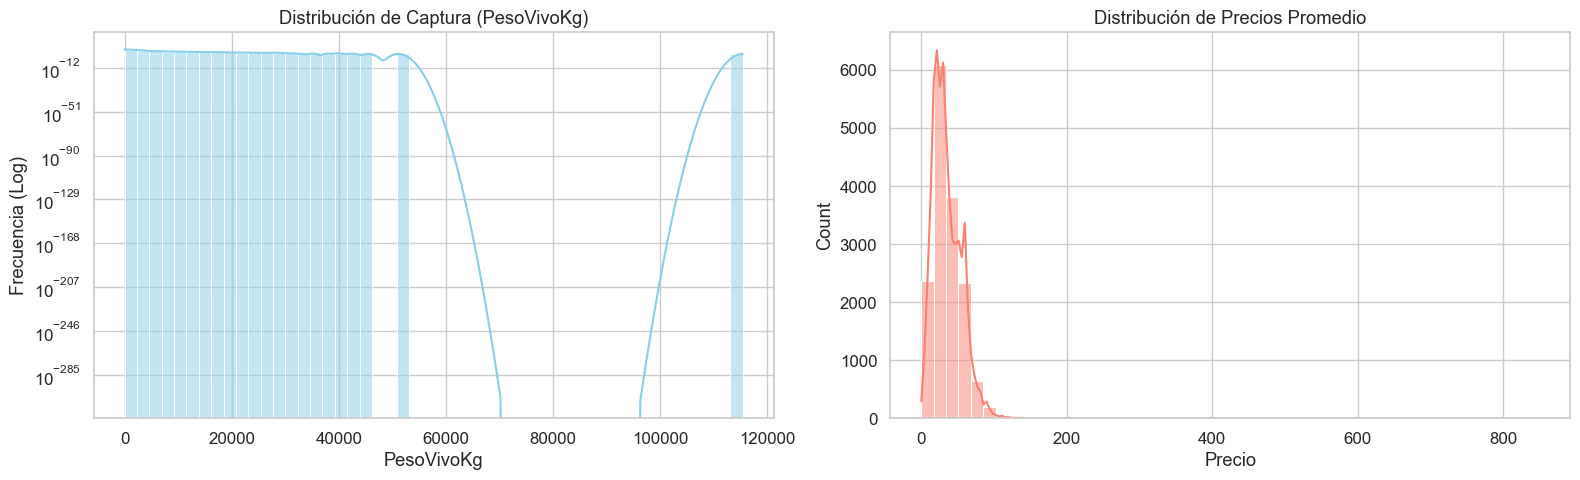

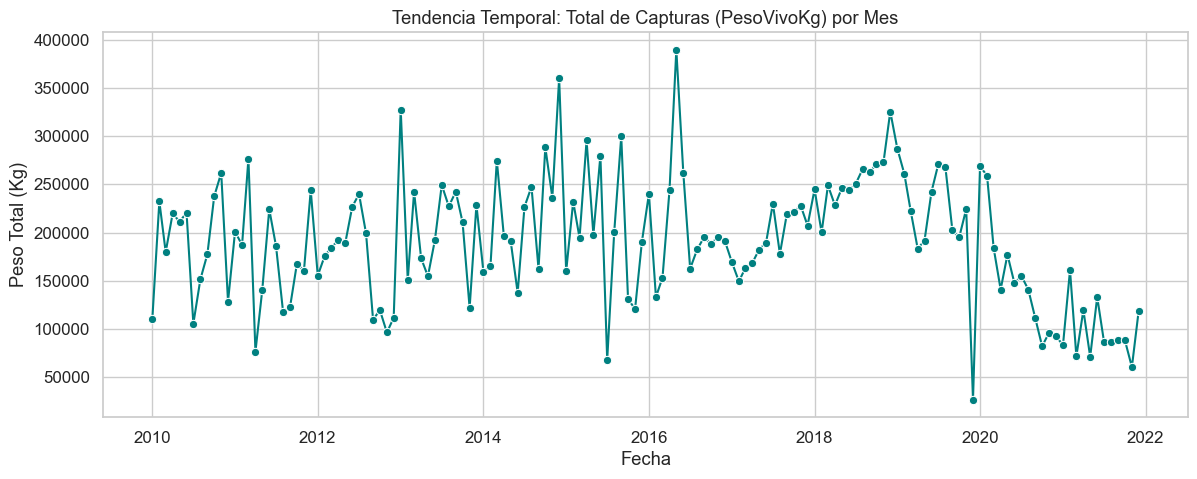

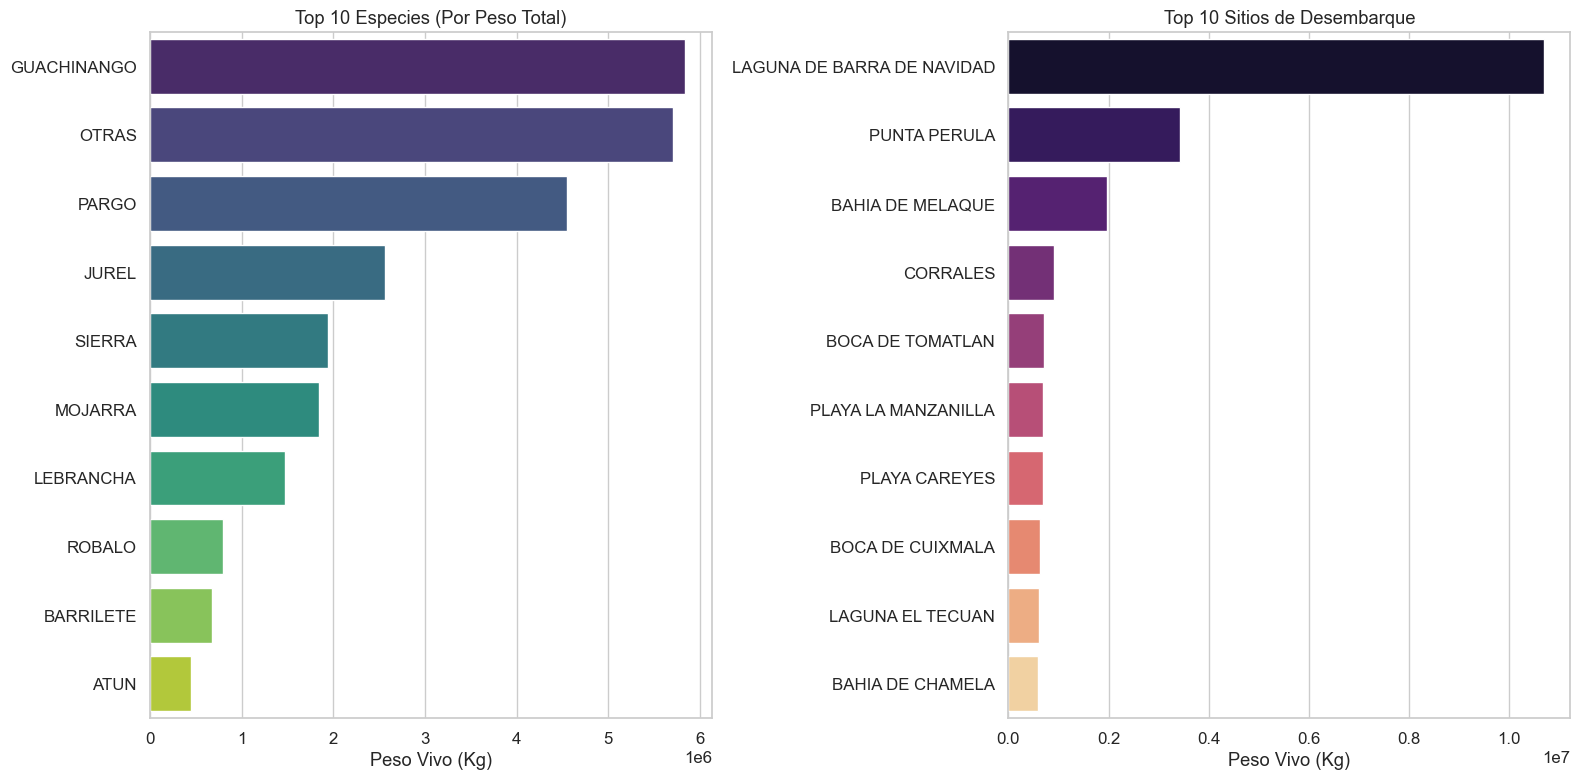

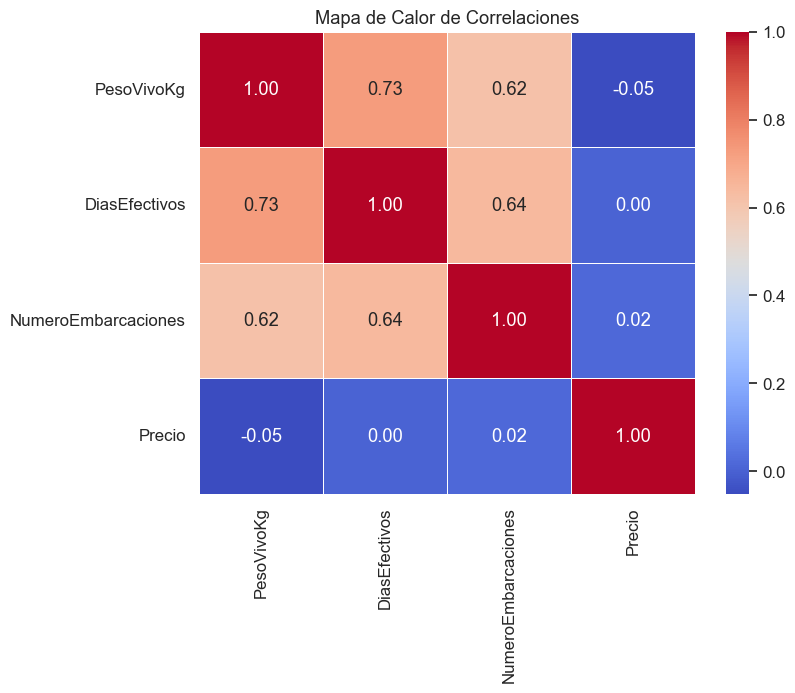

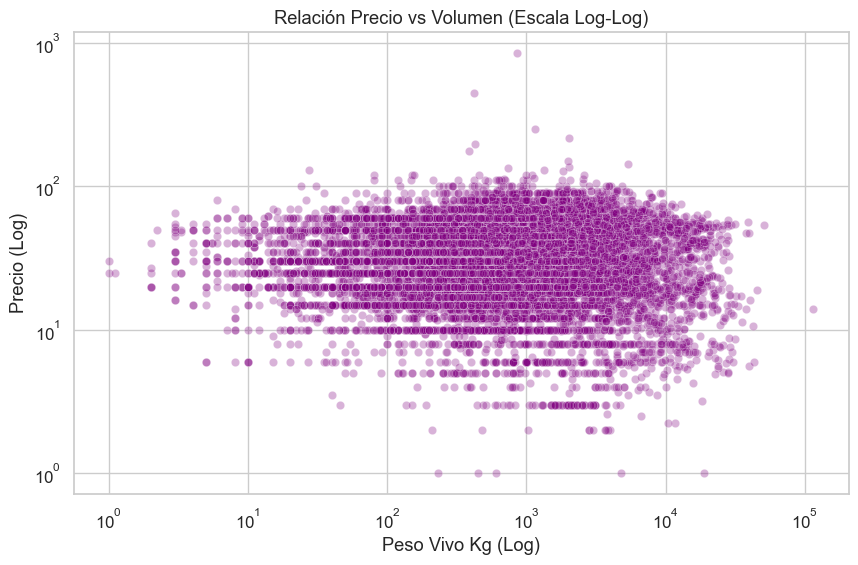

In [20]:
print("📊 Generando Reporte Descriptivo Completo...")

# --- 0. PREPARACIÓN EXTRA PARA VISUALIZACIÓN ---
if 'Anho' in df.columns and 'Mes' in df.columns:
    # Creamos fecha temporal para graficar
    df['Fecha'] = pd.to_datetime(df['Anho'].astype(str) + '-' + df['Mes'].astype(str) + '-01')
    has_date = True
else:
    has_date = False

# --- 1. ESTADÍSTICAS GENERALES ---
print("\n--- Resumen Estadístico (.describe) ---")
display(df[['PesoVivoKg', 'Precio', 'DiasEfectivos', 'NumeroEmbarcaciones']].describe().round(2))

# --- 2. DISTRIBUCIONES (Histogramas) ---
# Creamos una figura NUEVA para los histogramas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de Peso (Log)
sns.histplot(df['PesoVivoKg'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Captura (PesoVivoKg)')
axes[0].set_yscale('log')
axes[0].set_ylabel('Frecuencia (Log)')

# Histograma de Precio
sns.histplot(df['Precio'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de Precios Promedio')

plt.tight_layout()
plt.show() 

# --- 3. EVOLUCIÓN TEMPORAL ---
if has_date:
    plt.figure(figsize=(14, 5))
    temp = df.groupby('Fecha')['PesoVivoKg'].sum().reset_index()
    
    sns.lineplot(data=temp, x='Fecha', y='PesoVivoKg', marker='o', color='teal')
    plt.title('Tendencia Temporal: Total de Capturas (PesoVivoKg) por Mes')
    plt.ylabel('Peso Total (Kg)')
    plt.show()

# --- 4. TOP 10 ESPECIES Y SITIOS (EL CÓDIGO CORREGIDO) ---
# ¡IMPORTANTE! Creamos una NUEVA figura y nuevos ejes para esta sección
fig, axes = plt.subplots(1, 2, figsize=(16, 8)) 

# --- A. Top 10 Especies ---
# 1. Agrupar
top_especies = df.groupby('NombrePrincipal', observed=True)['PesoVivoKg'].sum().sort_values(ascending=False).head(10).reset_index()
# 2. Limpiar categorías fantasma
top_especies['NombrePrincipal'] = top_especies['NombrePrincipal'].astype(str)
# 3. Graficar
sns.barplot(
    data=top_especies, 
    x='PesoVivoKg', 
    y='NombrePrincipal', 
    ax=axes[0], 
    palette='viridis',
    order=top_especies['NombrePrincipal']
)
axes[0].set_title('Top 10 Especies (Por Peso Total)')
axes[0].set_xlabel('Peso Vivo (Kg)')
axes[0].set_ylabel('')

# --- B. Top 10 Sitios ---
# 1. Agrupar
top_sitios = df.groupby('NombreSitioDesembarque', observed=True)['PesoVivoKg'].sum().sort_values(ascending=False).head(10).reset_index()
# 2. Limpiar categorías fantasma
top_sitios['NombreSitioDesembarque'] = top_sitios['NombreSitioDesembarque'].astype(str)
# 3. Graficar
sns.barplot(
    data=top_sitios, 
    x='PesoVivoKg', 
    y='NombreSitioDesembarque', 
    ax=axes[1], 
    palette='magma',
    order=top_sitios['NombreSitioDesembarque']
)
axes[1].set_title('Top 10 Sitios de Desembarque')
axes[1].set_xlabel('Peso Vivo (Kg)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# --- 5. CORRELACIONES (Heatmap) ---
cols_corr = ['PesoVivoKg', 'DiasEfectivos', 'NumeroEmbarcaciones', 'Precio']
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

# --- 6. SCATTER PLOT: PRECIO VS VOLUMEN ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PesoVivoKg', y='Precio', alpha=0.3, color='purple')
plt.xscale('log')
plt.yscale('log')
plt.title('Relación Precio vs Volumen (Escala Log-Log)')
plt.xlabel('Peso Vivo Kg (Log)')
plt.ylabel('Precio (Log)')
plt.show()

## Definición de Variables (X e y)

En este paso separamos el dataset en dos componentes fundamentales para el entrenamiento de los modelos:

* **Variable Objetivo (`y`):** Es la columna que queremos predecir, en este caso **`PesoVivoKg`** (Biomasa).
* **Variables Predictoras (`X`):** Son todas las demás columnas que contienen la información (features) que el modelo utilizará para encontrar patrones.

### ⚠️ Prevención de "Data Leakage" (Fuga de Información)
Para garantizar que el modelo sea honesto y útil en un escenario real, es crítico eliminar columnas que tienen una relación matemática directa con el objetivo ("trampa").

Se eliminan las siguientes variables de la matriz `X`:
1.  **`PesoVivoKg`:** Es la variable a predecir.

In [21]:
# 1. Definimos la variable objetivo (Target)
y = df['PesoVivoKg']

# 2. Definimos las variables predictoras (Features)
# Primero creamos una lista de todo lo que NO queremos en X
columnas_a_eliminar = ['PesoVivoKg']

# 3. Creamos X eliminando y
X = df.drop(columns=columnas_a_eliminar)

# --- VERIFICACIÓN ---
print(f"Dimensiones de X (Predictoras): {X.shape}")
print(f"Dimensiones de y (Objetivo):    {y.shape}")
print("\nLas columnas que usaremos para predecir (X) son:")
print(list(X.columns))

Dimensiones de X (Predictoras): (15464, 8)
Dimensiones de y (Objetivo):    (15464,)

Las columnas que usaremos para predecir (X) son:
['Anho', 'Mes', 'NombrePrincipal', 'NombreSitioDesembarque', 'DiasEfectivos', 'NumeroEmbarcaciones', 'Precio', 'Fecha']


## Codificación de Variables Categóricas (One-Hot Encoding)

Los modelos matemáticos como SVM y la Regresión Polinómica requieren entradas exclusivamente numéricas. Para lograr esto con nuestras variables de texto (como `NombrePrincipal`, `Zona`), aplicamos una transformación llamada **One-Hot Encoding**.

### Estrategia: `drop_first=True`
Hemos configurado la transformación para eliminar la primera columna de cada categoría generada. Esto es una práctica estándar conocida como **evitar la "Trampa de las Variables Ficticias" (Dummy Variable Trap)**.

**¿Por qué es necesario?**
* **Reducción de Multicolinealidad:** Si una categoría tiene 3 opciones (A, B, C) y sabemos que no es A y no es B, matemáticamente *ya sabemos* que es C. Tener una columna explícita para C sería información redundante.
* **Estabilidad del Modelo:** Modelos sensibles a la correlación entre variables, como la **Regresión Polinómica** y el **SVM**, pueden sufrir problemas de convergencia o errores de cálculo si se mantiene esa redundancia perfecta.

Al final de este paso, nuestro dataset `X` será una matriz 100% numérica lista para el escalado.

In [22]:
# --- ONE-HOT ENCODING ---

# 1. Aplicamos la transformación a todo el conjunto X
# drop_first=True elimina la primera columna de cada categoría para evitar correlación perfecta
# (ej: si no es Lunes, ni Martes... ni Sábado, el modelo asume que es Domingo matemáticamente).
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Verificación de dimensiones
print("--- Antes del Encoding ---")
print(f"Columnas originales: {X.shape[1]}")
print(list(X.select_dtypes(include=['object']).columns)) # Muestra las que eran texto

print("\n--- Después del Encoding ---")
print(f"Total de columnas (Features) resultantes: {X_encoded.shape[1]}")
print(f"Filas (deben ser las mismas): {X_encoded.shape[0]}")

# 3. Vista previa de cómo quedó
# Mostramos las primeras 3 filas para que veas los 0s y 1s
display(X_encoded.head(3))

# 4. Actualizamos X para los siguientes pasos
X = X_encoded

--- Antes del Encoding ---
Columnas originales: 8
[]

--- Después del Encoding ---
Total de columnas (Features) resultantes: 80
Filas (deben ser las mismas): 15464


,Anho,Mes,DiasEfectivos,NumeroEmbarcaciones,Precio,Fecha,NombrePrincipal_BANDERA,NombrePrincipal_BARRILETE,NombrePrincipal_BERRUGATA,NombrePrincipal_BONITO,...,NombreSitioDesembarque_PLAYA LA MANZANILLA,NombreSitioDesembarque_PLAYA PIZOTA,NombreSitioDesembarque_PRESA RAMON CORONA,NombreSitioDesembarque_PUERTO VALLARTA,NombreSitioDesembarque_PUERTO VIEJO CHAMELA,NombreSitioDesembarque_PUNTA PERULA,NombreSitioDesembarque_PUNTA PEÃ‘ITAS,NombreSitioDesembarque_RIBERA CHIMO,NombreSitioDesembarque_RIO AMECA,NombreSitioDesembarque_RIO LAS JUNTAS
0,2010,1,6,2,10.0,2010-01-01,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2010,1,6,2,30.0,2010-01-01,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2010,1,3,1,30.0,2010-01-01,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


## División, Escalado y Validación Visual

Este bloque de código ejecuta tres pasos críticos para preparar los datos antes de entrenar los modelos (SVM, Random Forest y Regresión):

### 1. División del Dataset (Train/Test Split)
Separamos los datos en dos grupos para simular un escenario real de predicción:
* **Entrenamiento (80%):** Datos con los que los modelos aprenderán los patrones.
* **Prueba (20%):** Datos "invisibles" reservados exclusivamente para evaluar la precisión final.

### 2. Estandarización (StandardScaler)
Para que modelos matemáticos como SVM funcionen correctamente, todas las variables deben tener la misma importancia ("peso").
* Transformamos los datos para que tengan una **media de 0** y una **desviación estándar de 1**.
* **⚠️ Regla Anti-Fuga de Datos:** Calculamos el promedio y desviación *solo* con los datos de entrenamiento (`fit_transform`) y aplicamos esa regla fija a los datos de prueba (`transform`). Nunca permitimos que el modelo "vea" las estadísticas del set de prueba.

### 3. Validación Visual
Generamos una gráfica comparativa para verificar el proceso:
* **Gráfico Izquierdo (Original):** Muestra los valores reales (ej. días, barcos).
* **Gráfico Derecho (Escalado):** Muestra los mismos datos transformados a "Z-Scores".
* **Lo que buscamos:** La *forma* de la curva debe ser idéntica en ambos lados; solo debe cambiar la escala del eje X.

In [23]:
print(X.info())
# O simplemente:
print(X.select_dtypes(include=['datetime64', 'object']).columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15464 entries, 0 to 15463
Data columns (total 80 columns):
 #   Column                                                        Non-Null Count  Dtype         
---  ------                                                        --------------  -----         
 0   Anho                                                          15464 non-null  int64         
 1   Mes                                                           15464 non-null  int64         
 2   DiasEfectivos                                                 15464 non-null  int64         
 3   NumeroEmbarcaciones                                           15464 non-null  int64         
 4   Precio                                                        15464 non-null  float64       
 5   Fecha                                                         15464 non-null  datetime64[ns]
 6   NombrePrincipal_BANDERA                                       15464 non-null  bool          
 7   Nomb

In [24]:
# --- PASO DE LIMPIEZA ---
# Verificamos si 'Fecha' existe y la eliminamos
if 'Fecha' in X.columns:
    X = X.drop(columns=['Fecha'])
    print("Columna 'Fecha' eliminada correctamente.")
else:
    print("La columna 'Fecha' ya no está en el DataFrame.")

# --- AHORA SÍ, TU CÓDIGO NORMAL ---

# 1. DIVISIÓN (SPLIT)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. ESCALADO (SCALING)
scaler = StandardScaler()

# A) Ajustamos y transformamos X_train
X_train_scaled = scaler.fit_transform(X_train)

# B) Transformamos X_test
X_test_scaled = scaler.transform(X_test)

# Convertimos a DataFrame para visualización (Opcional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n¡Escalado exitoso!")
display(X_train_scaled.head(3))

Columna 'Fecha' eliminada correctamente.

¡Escalado exitoso!


,Anho,Mes,DiasEfectivos,NumeroEmbarcaciones,Precio,NombrePrincipal_BANDERA,NombrePrincipal_BARRILETE,NombrePrincipal_BERRUGATA,NombrePrincipal_BONITO,NombrePrincipal_CABRILLA,...,NombreSitioDesembarque_PLAYA LA MANZANILLA,NombreSitioDesembarque_PLAYA PIZOTA,NombreSitioDesembarque_PRESA RAMON CORONA,NombreSitioDesembarque_PUERTO VALLARTA,NombreSitioDesembarque_PUERTO VIEJO CHAMELA,NombreSitioDesembarque_PUNTA PERULA,NombreSitioDesembarque_PUNTA PEÃ‘ITAS,NombreSitioDesembarque_RIBERA CHIMO,NombreSitioDesembarque_RIO AMECA,NombreSitioDesembarque_RIO LAS JUNTAS
0,1.673196,-0.689094,-0.077907,-0.757390,1.194568,-0.048474,-0.170131,-0.131727,-0.106987,-0.117687,...,4.867506,-0.18491,-0.029832,-0.069225,-0.099386,-0.28577,-0.075436,-0.143322,-0.158454,-0.044999
1,1.673196,-0.398384,-0.099647,-0.519174,1.194568,-0.048474,-0.170131,-0.131727,-0.106987,-0.117687,...,-0.205444,-0.18491,-0.029832,-0.069225,-0.099386,-0.28577,-0.075436,-0.143322,-0.158454,-0.044999
2,0.165723,0.764457,-0.599661,-0.376245,-0.260199,-0.048474,-0.170131,-0.131727,-0.106987,-0.117687,...,4.867506,-0.18491,-0.029832,-0.069225,-0.099386,-0.28577,-0.075436,-0.143322,-0.158454,-0.044999


Dimensiones de Entrenamiento: (12371, 79)
Dimensiones de Prueba:        (3093, 79)

--- Ejemplo de datos escalados (primeras 3 filas de Train) ---


,Anho,Mes,DiasEfectivos,NumeroEmbarcaciones,Precio,NombrePrincipal_BANDERA,NombrePrincipal_BARRILETE,NombrePrincipal_BERRUGATA,NombrePrincipal_BONITO,NombrePrincipal_CABRILLA,...,NombreSitioDesembarque_PLAYA LA MANZANILLA,NombreSitioDesembarque_PLAYA PIZOTA,NombreSitioDesembarque_PRESA RAMON CORONA,NombreSitioDesembarque_PUERTO VALLARTA,NombreSitioDesembarque_PUERTO VIEJO CHAMELA,NombreSitioDesembarque_PUNTA PERULA,NombreSitioDesembarque_PUNTA PEÃ‘ITAS,NombreSitioDesembarque_RIBERA CHIMO,NombreSitioDesembarque_RIO AMECA,NombreSitioDesembarque_RIO LAS JUNTAS
0,1.673196,-0.689094,-0.077907,-0.757390,1.194568,-0.048474,-0.170131,-0.131727,-0.106987,-0.117687,...,4.867506,-0.18491,-0.029832,-0.069225,-0.099386,-0.28577,-0.075436,-0.143322,-0.158454,-0.044999
1,1.673196,-0.398384,-0.099647,-0.519174,1.194568,-0.048474,-0.170131,-0.131727,-0.106987,-0.117687,...,-0.205444,-0.18491,-0.029832,-0.069225,-0.099386,-0.28577,-0.075436,-0.143322,-0.158454,-0.044999
2,0.165723,0.764457,-0.599661,-0.376245,-0.260199,-0.048474,-0.170131,-0.131727,-0.106987,-0.117687,...,4.867506,-0.18491,-0.029832,-0.069225,-0.099386,-0.28577,-0.075436,-0.143322,-0.158454,-0.044999


--- Estadísticas de 'DiasEfectivos' ---

ANTES del Escalado (Datos Originales):
Media: 33.5836
Desv. Std: 46.0006
Rango: [1 a 776]

DESPUÉS del Escalado (StandardScaler):
Media: -0.0000 (Debe ser muy cercano a 0)
Desv. Std: 1.0000 (Debe ser muy cercano a 1)
Rango: [-0.71 a 16.14]


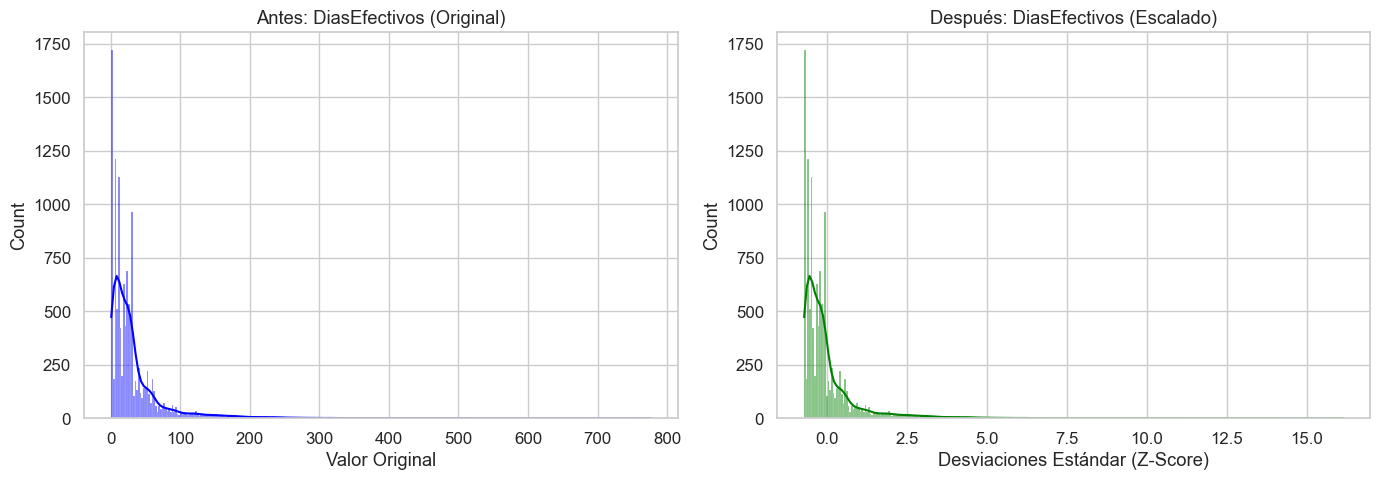

In [25]:
# 1. DIVISIÓN (SPLIT)
# Usamos un random_state para que los resultados sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de Entrenamiento: {X_train.shape}")
print(f"Dimensiones de Prueba:        {X_test.shape}")

# 2. ESCALADO (SCALING)
scaler = StandardScaler()

# A) Ajustamos el scaler SOLO con X_train y lo transformamos
X_train_scaled = scaler.fit_transform(X_train)

# B) Transformamos X_test usando la media y desviación que aprendimos de X_train
# (NUNCA hacemos fit con X_test)
X_test_scaled = scaler.transform(X_test)

# Convertimos a DataFrame para mantener la legibilidad (opcional, pero útil)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n--- Ejemplo de datos escalados (primeras 3 filas de Train) ---")
display(X_train_scaled.head(3))

# --- CONFIGURACIÓN ---
# Elige una variable numérica original para visualizar (NO una dummy de 0 y 1)
# Ejemplos probables en tu dataset: 'NumeroEmbarcaciones', 'DiasEfectivos', 'Precio'
variable_a_graficar = 'DiasEfectivos'  # <--- CAMBIA ESTO si quieres ver otra columna

# Verificamos si la columna existe antes de graficar
if variable_a_graficar in X_train.columns:
    
    # 1. Comparación Estadística
    print(f"--- Estadísticas de '{variable_a_graficar}' ---")
    print("\nANTES del Escalado (Datos Originales):")
    print(f"Media: {X_train[variable_a_graficar].mean():.4f}")
    print(f"Desv. Std: {X_train[variable_a_graficar].std():.4f}")
    print(f"Rango: [{X_train[variable_a_graficar].min()} a {X_train[variable_a_graficar].max()}]")

    print("\nDESPUÉS del Escalado (StandardScaler):")
    # Nota: Usamos la versión DataFrame que creamos en el paso anterior
    print(f"Media: {X_train_scaled[variable_a_graficar].mean():.4f} (Debe ser muy cercano a 0)")
    print(f"Desv. Std: {X_train_scaled[variable_a_graficar].std():.4f} (Debe ser muy cercano a 1)")
    print(f"Rango: [{X_train_scaled[variable_a_graficar].min():.2f} a {X_train_scaled[variable_a_graficar].max():.2f}]")

    # 2. Comparación Visual
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico A: Original
    sns.histplot(X_train[variable_a_graficar], kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f"Antes: {variable_a_graficar} (Original)")
    axes[0].set_xlabel("Valor Original")

    # Gráfico B: Escalado
    sns.histplot(X_train_scaled[variable_a_graficar], kde=True, ax=axes[1], color='green')
    axes[1].set_title(f"Después: {variable_a_graficar} (Escalado)")
    axes[1].set_xlabel("Desviaciones Estándar (Z-Score)")

    plt.tight_layout()
    plt.show()

else:
    print(f"⚠️ La columna '{variable_a_graficar}' no se encuentra en X_train.")
    print("Columnas disponibles:", list(X_train.columns))

# 5. Modelado

## Configuración de Modelos y Métricas de Evaluación

Antes de entrenar, definimos una función reutilizable (`evaluar_modelo`) que nos permitirá medir el rendimiento de los tres algoritmos bajo las mismas reglas.

**Métricas Clave:**
* **$R^2$ (Coeficiente de Determinación):** Indica qué porcentaje de la variabilidad de la biomasa es explicado por el modelo.
    * *Objetivo:* Lo más cercano a **1.0**.
* **RMSE (Raíz del Error Cuadrático Medio):** Mide cuánto se equivoca el modelo en promedio, en las mismas unidades que nuestros datos (Kilogramos). Penaliza fuertemente los errores grandes.
    * *Objetivo:* Lo más bajo posible.
* **MAE (Error Absoluto Medio):** El promedio directo de los errores (diferencia entre predicción y realidad).

In [26]:
# Función auxiliar para evaluar y reportar resultados
def evaluar_modelo(modelo, X_test_data, y_test_data, nombre_modelo):
    # 1. Predecir
    y_pred = modelo.predict(X_test_data)
    
    # 2. Calcular métricas
    mse = mean_squared_error(y_test_data, y_pred)
    rmse = np.sqrt(mse) # Error cuadrático medio (en las mismas unidades que el objetivo, Kg)
    mae = mean_absolute_error(y_test_data, y_pred)
    r2 = r2_score(y_test_data, y_pred) # Coeficiente de determinación (que tan bien se ajusta)
    
    # 3. Imprimir reporte
    print(f"--- Resultados para: {nombre_modelo} ---")
    print(f"✅ R2 Score (Precisión): {r2:.4f} (El máximo ideal es 1.0)")
    print(f"📉 RMSE (Error Promedio): {rmse:.2f} Kg")
    print(f"📉 MAE (Error Absoluto):  {mae:.2f} Kg")
    print("-" * 40 + "\n")
    
    return r2, rmse

# --- FUNCIÓN AUXILIAR PARA GRAFICAR ---
def visualizar_prediccion(y_real, y_pred, titulo, r2):
    plt.figure(figsize=(8, 6))
    
    # 1. Puntos de dispersión (Real vs Predicho)
    sns.scatterplot(x=y_real, y=y_pred, alpha=0.5, color='blue', edgecolor='k')
    
    # 2. Línea diagonal perfecta (Ideal)
    max_val = max(y_real.max(), y_pred.max())
    min_val = min(y_real.min(), y_pred.min())
    plt.plot([min_val, max_val], [min_val, max_val], '--', color='red', linewidth=2, label='Predicción Perfecta')
    
    # 3. Etiquetas
    plt.title(f"{titulo} - R2: {r2:.3f}", fontsize=14)
    plt.xlabel("Biomasa Real (Kg)")
    plt.ylabel("Biomasa Predicha (Kg)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Modelo 1: Random Forest Regressor

**¿Qué es?**
Es un método de ensamble que crea múltiples "árboles de decisión" durante el entrenamiento (en este caso, 100 árboles). Para dar una predicción final, promedia el resultado de todos los árboles individuales.

**¿Por qué usarlo aquí?**
* Es muy robusto frente a "ruido" en los datos.
* Maneja excelentemente las relaciones no lineales (la biomasa no siempre sube en línea recta con el esfuerzo pesquero).
* No suele requerir una configuración de parámetros muy compleja para dar buenos resultados iniciales.

⏳ --- ENTRENANDO RANDOM FOREST ---
--- Resultados para: Random Forest ---
✅ R2 Score (Precisión): 0.8187 (El máximo ideal es 1.0)
📉 RMSE (Error Promedio): 1468.96 Kg
📉 MAE (Error Absoluto):  600.06 Kg
----------------------------------------



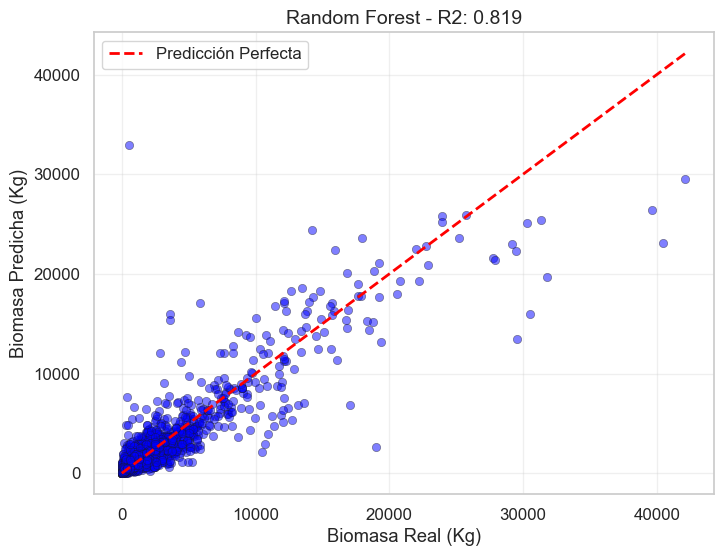

In [35]:
# ==========================================
# MODELO 1: RANDOM FOREST
# ==========================================
print("⏳ --- ENTRENANDO RANDOM FOREST ---")

# Instanciamos y Entrenamos
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Evaluamos
r2_rf, rmse_rf = evaluar_modelo(rf_model, X_test_scaled, y_test, "Random Forest")

# GRAFICAMOS RESULTADO
y_pred_rf = rf_model.predict(X_test_scaled)
visualizar_prediccion(y_test, y_pred_rf, "Random Forest", r2_rf)


## Modelo 2: Máquina de Soporte Vectorial (SVR)

**¿Qué es?**
El *Support Vector Regressor* intenta encontrar una curva (hiperplano) que se ajuste a los datos dentro de un margen de error tolerado ($\epsilon$).

**Configuración Específica:**
* **Kernel 'rbf':** Usamos una función de base radial (Radial Basis Function). Esto permite al modelo aprender curvas complejas y formas "orgánicas", lo cual es ideal para datos biológicos que no siguen líneas rectas simples.
* **Nota de Rendimiento:** Este modelo es matemáticamente intensivo. Dado el tamaño del dataset, puede tardar más tiempo en entrenar que los otros modelos.


⏳ --- ENTRENANDO SVM (SVR) ---
--- Resultados para: SVM ---
✅ R2 Score (Precisión): 0.6207 (El máximo ideal es 1.0)
📉 RMSE (Error Promedio): 2124.87 Kg
📉 MAE (Error Absoluto):  807.78 Kg
----------------------------------------



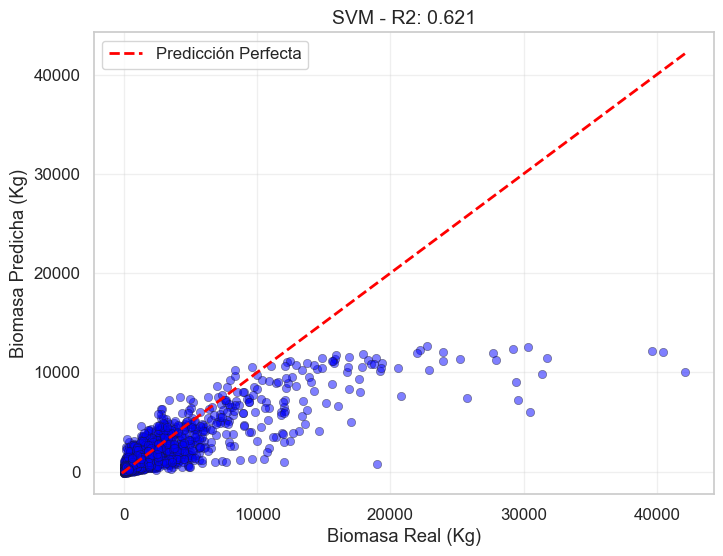

In [34]:
# ==========================================
# MODELO 2: SVM (SVR)
# ==========================================
print("\n⏳ --- ENTRENANDO SVM (SVR) ---")

# Instanciamos y Entrenamos
svm_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svm_model.fit(X_train_scaled, y_train)

# Evaluamos
r2_svm, rmse_svm = evaluar_modelo(svm_model, X_test_scaled, y_test, "SVM")

# GRAFICAMOS RESULTADO
y_pred_svm = svm_model.predict(X_test_scaled)
visualizar_prediccion(y_test, y_pred_svm, "SVM", r2_svm)

## Modelo 3: Regresión Polinómica (Grado 2)

**¿Qué es?**
Técnicamente, es una Regresión Lineal, pero aplicada a datos transformados. En lugar de usar solo las variables originales ($A, B$), creamos nuevas variables elevadas al cuadrado y multiplicadas entre sí ($A^2, B^2, A \times B$).

**¿Por qué Grado 2?**
* Permite capturar curvas simples (parábolas). Por ejemplo, puede detectar si la captura aumenta con el esfuerzo pesquero hasta cierto punto y luego disminuye (saturación).
* **Precaución:** No usamos Grado 3 o superior porque, al tener muchas columnas por el *One-Hot Encoding*, el número de variables explotaría (decenas de miles), causando lentitud extrema y *overfitting* (memorizar los datos en lugar de aprender).


⏳ --- ENTRENANDO REGRESIÓN POLINÓMICA ---
   (Transformando variables numéricas...)
--- Resultados para: Regresión Polinómica ---
✅ R2 Score (Precisión): 0.7609 (El máximo ideal es 1.0)
📉 RMSE (Error Promedio): 1687.18 Kg
📉 MAE (Error Absoluto):  921.72 Kg
----------------------------------------



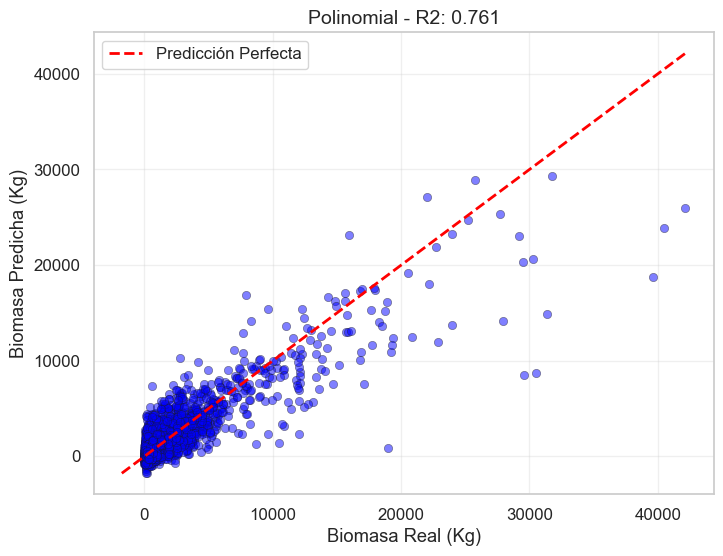

In [33]:
# ==========================================
# MODELO 3: REGRESIÓN POLINÓMICA (OPTIMIZADA)
# ==========================================
print("\n⏳ --- ENTRENANDO REGRESIÓN POLINÓMICA ---")
print("   (Transformando variables numéricas...)")

# 1. Identificamos columnas
col_numericas = [col for col in X_train_scaled.columns if X_train_scaled[col].nunique() > 2]
col_dummies = [col for col in X_train_scaled.columns if X_train_scaled[col].nunique() <= 2]

# 2. Separamos y Transformamos
X_train_num = X_train_scaled[col_numericas]
X_train_cat = X_train_scaled[col_dummies]
X_test_num = X_test_scaled[col_numericas]
X_test_cat = X_test_scaled[col_dummies]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_num_poly = poly.fit_transform(X_train_num)
X_test_num_poly = poly.transform(X_test_num)

# 3. Unimos todo
X_train_final = np.hstack([X_train_num_poly, X_train_cat])
X_test_final = np.hstack([X_test_num_poly, X_test_cat])

# 4. Entrenamos Regresión Lineal sobre la matriz optimizada
poly_model = LinearRegression()
poly_model.fit(X_train_final, y_train)

# 5. Evaluamos
r2_poly, rmse_poly = evaluar_modelo(poly_model, X_test_final, y_test, "Regresión Polinómica")

# GRAFICAMOS RESULTADO
# ¡Ojo! Aquí usamos X_test_final para predecir
y_pred_poly = poly_model.predict(X_test_final) 
visualizar_prediccion(y_test, y_pred_poly, "Polinomial", r2_poly)

## Comparación Final y Selección del Mejor Modelo

En esta etapa consolidamos los resultados obtenidos (`R2` y `RMSE`) de los tres modelos para tomar una decisión basada en datos.

**Generaremos dos salidas:**
1.  **Tabla Resumen:** Una vista limpia de los números exactos.
2.  **Gráficos de Barras:**
    * **Precisión ($R^2$):** Buscamos la barra más alta (cercana a 1.0).
    * **Error (RMSE):** Buscamos la barra más baja (menor error en Kg).

El script identificará automáticamente cuál modelo tuvo el menor error y lo sugerirá como la mejor opción para tus predicciones de biomasa.

🏆 TABLA DE POSICIONES:


,Modelo,R2 Score,RMSE (Kg)
0,Random Forest,0.818721,1468.964491
1,Polinomial (Grado 2),0.760862,1687.178363
2,SVM (SVR),0.620692,2124.872445


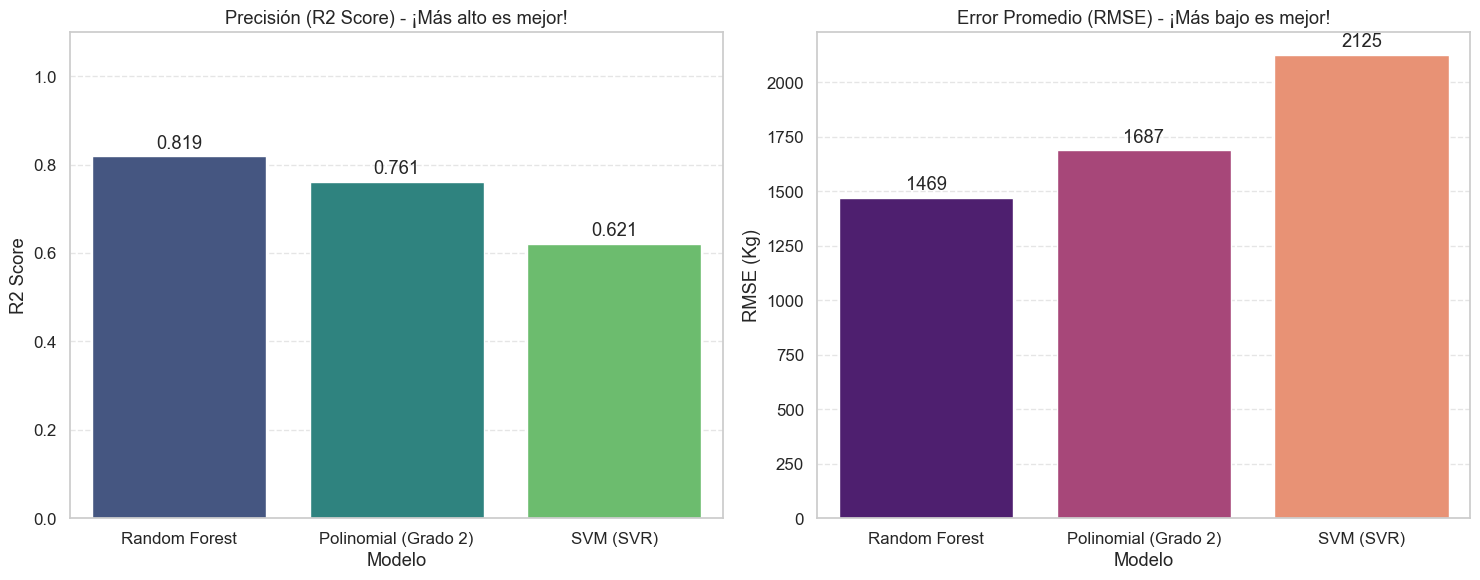


✅ RECOMENDACIÓN FINAL:
El modelo ganador es: **Random Forest**
Logró explicar el 81.9% de la variabilidad con un error de 1469.0 Kg.


In [30]:
# --- COMPARACIÓN DE MODELOS ---

# 1. Creamos un DataFrame con los resultados guardados
resultados = {
    'Modelo': ['Random Forest', 'SVM (SVR)', 'Polinomial (Grado 2)'],
    'R2 Score': [r2_rf, r2_svm, r2_poly],
    'RMSE (Kg)': [rmse_rf, rmse_svm, rmse_poly]
}

df_resultados = pd.DataFrame(resultados)

# Ordenamos por RMSE (el menor error arriba) para ver al ganador primero
df_resultados = df_resultados.sort_values(by='RMSE (Kg)', ascending=True).reset_index(drop=True)

print("🏆 TABLA DE POSICIONES:")
display(df_resultados)

# 2. Visualización Gráfica
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico A: R2 Score (Más alto es mejor)
sns.barplot(data=df_resultados, x='Modelo', y='R2 Score', palette='viridis', ax=axes[0])
axes[0].set_title('Precisión (R2 Score) - ¡Más alto es mejor!')
axes[0].set_ylim(0, 1.1) # Fijamos el límite para ver qué tan cerca está del 1.0
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Añadimos los valores sobre las barras
for i in axes[0].containers:
    axes[0].bar_label(i, fmt='%.3f', padding=3)

# Gráfico B: RMSE (Más bajo es mejor)
sns.barplot(data=df_resultados, x='Modelo', y='RMSE (Kg)', palette='magma', ax=axes[1])
axes[1].set_title('Error Promedio (RMSE) - ¡Más bajo es mejor!')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Añadimos los valores sobre las barras
for i in axes[1].containers:
    axes[1].bar_label(i, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

# 3. Veredicto Automático
mejor_modelo = df_resultados.iloc[0] # El primero de la lista (porque ordenamos por error)
print(f"\n✅ RECOMENDACIÓN FINAL:")
print(f"El modelo ganador es: **{mejor_modelo['Modelo']}**")
print(f"Logró explicar el {mejor_modelo['R2 Score']*100:.1f}% de la variabilidad con un error de {mejor_modelo['RMSE (Kg)']:.1f} Kg.")

🧪 Entrenando los 3 modelos usando Logaritmo del Objetivo (Log-Target)...
   -> Usando matriz polinómica para el tercer modelo.


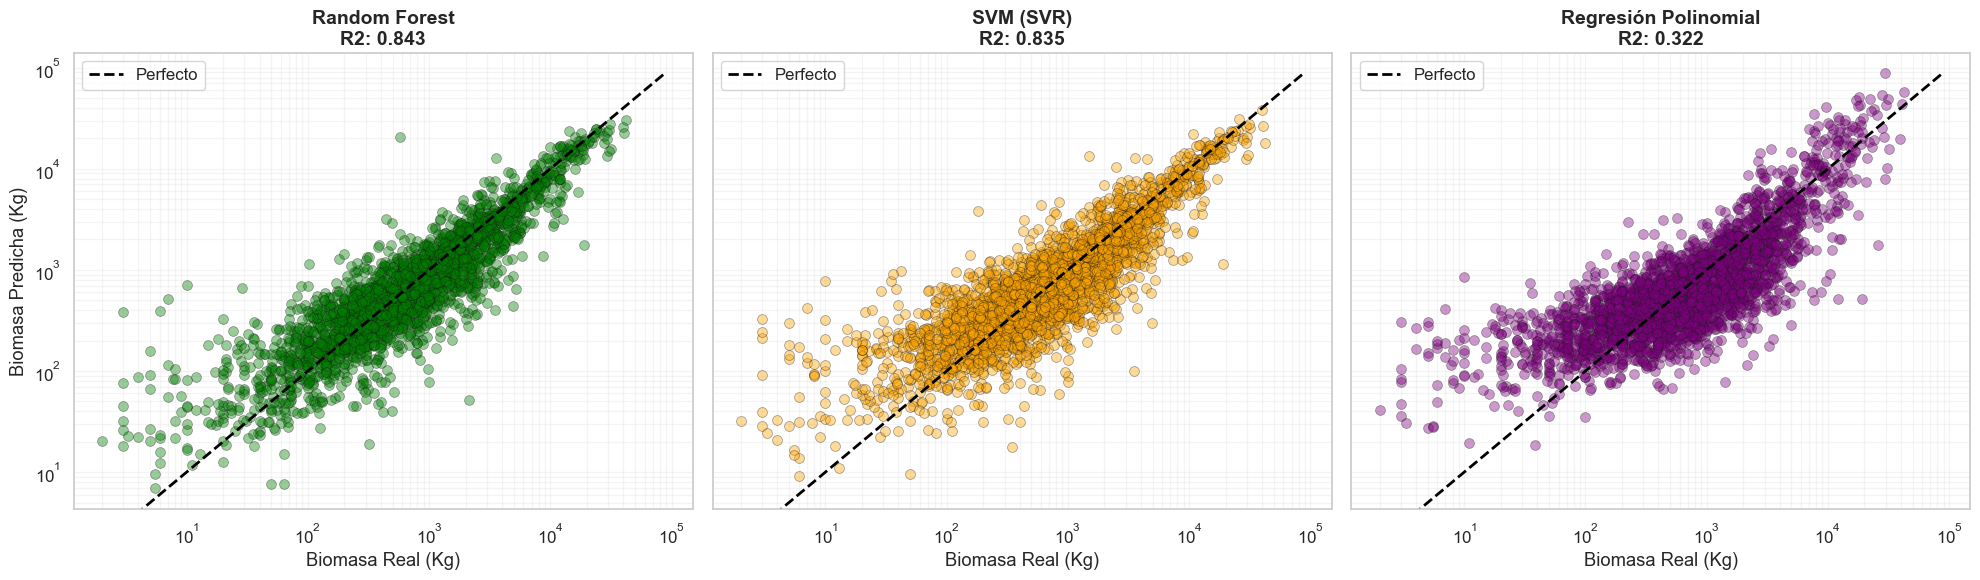


📊 RESUMEN DE PRECISIÓN (R2 SCORE):
Random Forest: 0.8426
SVM (SVR): 0.8347
Regresión Polinomial: 0.3217


In [31]:
# --- CONFIGURACIÓN: ENTRENAMIENTO LOGARÍTMICO ---
print("🧪 Entrenando los 3 modelos usando Logaritmo del Objetivo (Log-Target)...")

# 1. Transformamos el objetivo (y) a escala logarítmica
# Usamos log1p para manejar ceros sin errores matemáticos
y_train_log = np.log1p(y_train)
# Nota: y_test se queda en escala real para la evaluación final

# 2. Configuración de Gráficos
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
modelos_resultados = []

# ==========================================
# MODELO 1: RANDOM FOREST (LOG)
# ==========================================
rf_log = RandomForestRegressor(n_estimators=100, random_state=42)
rf_log.fit(X_train_scaled, y_train_log)

# Predicción y Reversión
pred_log = rf_log.predict(X_test_scaled)
pred_real_rf = np.expm1(pred_log) # Revertir logaritmo

r2_rf = r2_score(y_test, pred_real_rf)
modelos_resultados.append(("Random Forest", pred_real_rf, r2_rf, "green"))


# ==========================================
# MODELO 2: SVM (LOG)
# ==========================================
# SVM suele funcionar mejor con C alto en escala logarítmica
svm_log = SVR(kernel='rbf', C=10, epsilon=0.1)
svm_log.fit(X_train_scaled, y_train_log)

# Predicción y Reversión
pred_log = svm_log.predict(X_test_scaled)
pred_real_svm = np.expm1(pred_log)

r2_svm = r2_score(y_test, pred_real_svm)
modelos_resultados.append(("SVM (SVR)", pred_real_svm, r2_svm, "orange"))


# ==========================================
# MODELO 3: REGRESIÓN (LOG-LINEAL)
# ==========================================
# Usaremos una regresión lineal sobre las variables.
# Al predecir Log(Y), esto matemáticamente equivale a una curva exponencial.
reg_log = LinearRegression()

# Si existe la matriz polinómica optimizada (X_train_final), la usamos. Si no, usamos X_scaled.
if 'X_train_final' in locals() and 'X_test_final' in locals():
    print("   -> Usando matriz polinómica para el tercer modelo.")
    reg_log.fit(X_train_final, y_train_log)
    pred_log = reg_log.predict(X_test_final)
else:
    print("   -> Usando matriz estándar para el tercer modelo (Log-Lineal).")
    reg_log.fit(X_train_scaled, y_train_log)
    pred_log = reg_log.predict(X_test_scaled)

pred_real_poly = np.expm1(pred_log)

r2_poly = r2_score(y_test, pred_real_poly)
modelos_resultados.append(("Regresión Polinomial", pred_real_poly, r2_poly, "purple"))


# ==========================================
# GRAFICACIÓN FINAL
# ==========================================
max_val_real = y_test.max()
max_val_pred = max(pred_real_rf.max(), pred_real_svm.max(), pred_real_poly.max())
limite = max(max_val_real, max_val_pred)

for i, (nombre, predicciones, r2, color) in enumerate(modelos_resultados):
    ax = axes[i]
    
    # Puntos
    sns.scatterplot(x=y_test, y=predicciones, alpha=0.4, color=color, ax=ax, edgecolor='k', s=50)
    
    # Línea Ideal
    ax.plot([0, limite], [0, limite], '--', color='black', linewidth=2, label='Perfecto')
    
    # Títulos y Estilos
    ax.set_title(f"{nombre}\nR2: {r2:.3f}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Biomasa Real (Kg)")
    if i == 0: ax.set_ylabel("Biomasa Predicha (Kg)")
    
    # Escalas Logarítmicas en los ejes (Para ver mejor la distribución)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()

# Resumen numérico rápido
print("\n📊 RESUMEN DE PRECISIÓN (R2 SCORE):")
for nombre, _, r2, _ in modelos_resultados:
    print(f"{nombre}: {r2:.4f}")

In [32]:
# --- 1. EXTRACCIÓN DE DATOS ---
top_n = 15

# Función auxiliar para obtener el dataframe de importancia
def obtener_importancia(modelo, X_data):
    imp = modelo.feature_importances_
    df = pd.DataFrame({'Variable': X_data.columns, 'Importancia': imp})
    return df.sort_values('Importancia', ascending=False).reset_index(drop=True)

# Obtenemos los rankings de ambos modelos
df_normal = obtener_importancia(rf_model, X_test)
df_log = obtener_importancia(rf_log, X_test)

# --- 2. CREACIÓN DE TABLA COMPARATIVA ---
comparativa = pd.DataFrame({
    'Ranking': range(1, top_n + 1),
    'Variable (RF Normal)': df_normal.head(top_n)['Variable'],
    'Peso (Normal)': df_normal.head(top_n)['Importancia'],
    'Variable (RF Log)': df_log.head(top_n)['Variable'],
    'Peso (Log)': df_log.head(top_n)['Importancia']
})

# --- 3. ESTILIZADO (ALTO CONTRASTE) ---
print(f"\n📊 COMPARACIÓN TOP {top_n} DRIVERS: MODELO NORMAL VS LOGARÍTMICO")

estilo_final = comparativa.style.format({
    'Peso (Normal)': '{:.1%}',
    'Peso (Log)': '{:.1%}'
}).bar(
    subset=['Peso (Normal)', 'Peso (Log)'], 
    color='#63C47F',  # Un verde un poco más intenso pero legible
    vmin=0, 
    vmax=0.6
).set_properties(**{
    'text-align': 'left',
    'padding': '6px',
    'color': 'black',             # <--- FORZAMOS TEXTO NEGRO EN EL CUERPO
    'background-color': 'white',  # Fondo blanco para asegurar contraste
    'border-bottom': '1px solid #dcdcdc'
}).set_table_styles([
    # Estilo de los Encabezados (Títulos)
    {
        'selector': 'th', 
        'props': [
            ('background-color', '#d9d9d9'), # Gris más oscuro para que se vea la caja
            ('color', 'black'),              # <--- FORZAMOS TEXTO NEGRO EN TITULOS
            ('font-weight', 'bold'),         # Negritas para que resalte
            ('text-align', 'center'),
            ('padding', '8px'),
            ('border', '1px solid white')
        ]
    },
    # Hover (Efecto al pasar el mouse)
    {
        'selector': 'tbody tr:hover', 
        'props': [('background-color', '#f0f0f0')]
    }
]).hide(axis='index')

display(estilo_final)


📊 COMPARACIÓN TOP 15 DRIVERS: MODELO NORMAL VS LOGARÍTMICO


Ranking,Variable (RF Normal),Peso (Normal),Variable (RF Log),Peso (Log)
1,DiasEfectivos,53.4%,DiasEfectivos,49.4%
2,NombreSitioDesembarque_LAGUNA DE BARRA DE NAVIDAD,14.4%,NumeroEmbarcaciones,8.5%
3,Precio,6.7%,Anho,6.2%
4,NumeroEmbarcaciones,6.6%,Precio,5.6%
5,NombreSitioDesembarque_OTROS,4.2%,Mes,4.3%
6,Mes,3.5%,NombreSitioDesembarque_LAGUNA DE BARRA DE NAVIDAD,3.0%
7,Anho,3.1%,NombrePrincipal_GUACHINANGO,1.3%
8,NombrePrincipal_MOJARRA,1.2%,NombreSitioDesembarque_DESEMBARCADERO LA MANZANILLA,1.2%
9,NombrePrincipal_GUACHINANGO,1.1%,NombreSitioDesembarque_PLAYA LA MANZANILLA,1.2%
10,NombrePrincipal_PARGO,0.7%,NombreSitioDesembarque_BAHIA DE TEHUAMIXTLE,1.1%


## Interpretación de Resultados: Modelo Normal vs. Logarítmico

Al comparar la importancia de las variables (*feature importance*) entre el modelo de **Random Forest Normal** (entrenado con datos crudos) y el **Random Forest Logarítmico** (entrenado con `log(Biomasa)`), observamos diferencias clave que revelan la naturaleza de los datos pesqueros.

### 1. Diferencias Técnicas: ¿Por qué cambian los rankings?

* **Modelo Normal (Enfoque en Volumen):** Este modelo intenta minimizar el error en kilogramos absolutos. Por lo tanto, es muy sensible a los **valores extremos (outliers)**. Si un sitio específico tiene capturas masivas esporádicas, el modelo le dará un peso desproporcionado para intentar predecir esos picos.
* **Modelo Logarítmico (Enfoque en Tendencia):** La transformación logarítmica "suaviza" los picos y reduce la distancia entre valores pequeños y gigantes. Esto obliga al modelo a buscar **relaciones estructurales y constantes** (patrones que se cumplen siempre) en lugar de memorizar eventos aislados de gran magnitud.

### 2. Hallazgos Biológicos y Pesqueros

Los resultados comparativos nos cuentan la siguiente historia:

* **`DiasEfectivos` es el Factor Dominante:**
    En ambos modelos, el tiempo de pesca es la variable #1 indiscutible (~50% de importancia). Esto valida la coherencia de los datos: el esfuerzo en tiempo es el predictor más fuerte de la captura.

* **El Efecto "Barra de Navidad" (Outliers vs. Estructura):**
    * En el **Modelo Normal**, *Laguna de Barra de Navidad* es la 2ª variable más importante (14.4%). Esto sugiere que este sitio tiene descargas de volumen excepcionalmente alto que el modelo intenta capturar.
    * En el **Modelo Logarítmico**, cae al 6º lugar (3.0%). Al eliminar el efecto de los volúmenes extremos, el sitio pierde protagonismo frente a variables más técnicas.

* **El Esfuerzo Pesquero (`NumeroEmbarcaciones`):**
    Esta variable sube del puesto 4 al **puesto 2** en el modelo logarítmico (8.5%). Esto es positivo, ya que indica que la relación técnica *"Más Barcos = Más Pesca"* es robusta y generalizable a través de todos los sitios, una vez que se limpia el ruido de los outliers.

* **Estacionalidad (`Mes` y `Anho`):**
    Las variables temporales ganan peso en el modelo logarítmico. Esto indica que la transformación permite al modelo captar mejor los **ciclos biológicos y tendencias anuales** de la pesquería, que antes quedaban ocultos por la magnitud de las capturas en sitios específicos.

### 3. Conclusión
El cambio en los rankings confirma la presencia de **valores atípicos fuertes** en ciertos sitios de desembarque. Mientras el modelo Normal es útil para predecir inventarios totales (volumen bruto), el modelo Logarítmico ofrece una visión más clara de la **dinámica pesquera subyacente**, destacando mejor el impacto del esfuerzo (barcos) y la temporalidad.